In [1]:
import os
import json
import numpy as np
import json_repair
from tqdm.auto import tqdm
from collections import defaultdict

def load_jsonl_data(path):
    data = []
    with open(path) as reader:
        for row in reader:
            data.append(json.loads(row))
    return data

def write_jsonl_data(data, path):
    with open(path, "w") as writer:
        for row in data:
            writer.write(json.dumps(row) + "\n")

def _parse_json_response(text: str, keys: list) -> dict:
    import re
    
    try:
        try:
            match = re.search(r"```json\s*([\s\S]*?)\s*```", text)

            json_str = match.group(1).strip()
            result = json_repair.loads(json_str)
            
        except:
            result = json_repair.loads(text)
        for key in keys:
            if key not in result:
                result[key] = None

        return result

    except Exception as e:
        response = {k: None for k in keys}
        return response

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dataclasses import dataclass, field, fields, asdict

@dataclass
class UserProfile:
    user_id: str
    religious: str
    employment: str
    marital: str
    race: str
    income: str
    area: str
    age: str
    gender: str
    bigfive: dict
    personality: list
    preferences: list
    preferences_value: list
    extra: dict = field(default_factory=dict)

    @classmethod
    def from_dict(cls, data: dict):
        data = {k.lower(): v for k, v in data.items()}

        field_names = {f.name for f in fields(cls) if f.name != "extra"}
        
        known = {name: data.get(name, None) for name in field_names}
        extra = {k: v for k, v in data.items() if k not in field_names}
        
        return cls(known, extra=extra)

    def to_dict(self) -> dict:
        base = asdict(self)
        base.update(self.extra)
        base.pop("extra", None)
        return base

    def desc(self, keys_to_drop: list = []):
        """
        Convert structured profile to a descriptive string.
        """
        base_info_parts = []

        attrs = [
            ("gender", "{}"),
            ("age", "{}"),
            ("race", "{}"),
            ("marital", "{}"),
            ("religious", "user's religion is {}"),
            ("area", "usually resides in {}"),
        ]

        for attr_name, fmt in attrs:
            if attr_name in keys_to_drop:
                continue
            value = getattr(self, attr_name, None)
            if not value:
                continue
            if attr_name == "religious":
                if value == "No religion":
                    base_info_parts.append("no religious affiliation")
                else:
                    base_info_parts.append(fmt.format(value))
            else:
                base_info_parts.append(fmt.format(value))

        base_info = ", ".join(base_info_parts)

        politics_econ_parts = []
        if "income" not in keys_to_drop and self.income:
            politics_econ_parts.append(f"the income level is {self.income}")
        if "employment" not in keys_to_drop and self.employment:
            politics_econ_parts.append(f"{self.employment}")
        politics_econ_text = ", ".join(politics_econ_parts)

        personality_text = ""
        if "personality" not in keys_to_drop and self.personality:
            personality_text = "Personality traits include: " + "、".join(self.personality)

        preferences_text = ""
        if "preferences" not in keys_to_drop and self.preferences:
            preferences_text = "Preferences expressed in daily life and interactions include: " + " ".join(self.preferences)

        parts = [base_info, politics_econ_text, personality_text, preferences_text]
        return ". ".join([p for p in parts if p])

    def __str__(self) -> str:
        return self.desc()

# User Agent Performance

In [ ]:
theme = 'user-sim-qwen3-32b_total_sport_mental'
root = '/remote-home/fyduan/user_simulation/ai_assistant/logs'

base_dir = os.path.join(root, theme)
paths = []

for root, dirs, files in os.walk(base_dir):
    for f in files:
        if f.startswith("sim_log"):
            paths.append(os.path.join(root, f))

convs = []

turns = []

for p in paths:
    data = json.load(open(p))
    for x in data:
        conv = ''
        if len(x['dialogue']) < 1:
            continue
        for turn in x['dialogue']:
            if turn['role'] == 'user':
                conv += f"[User]{turn['content']}\n"
            else:
                conv += f"[Assistant]{turn['content']}\n"

        turns.append(len(x['dialogue']) / 2)

        # profile = x['user']['profile_str']
        profile = str(UserProfile.from_dict(x['user']))
        convs.append({
            "user_profile": str(profile),
            "dialogue_scene": x['event']['dialogue_scene'],
            "intent": x['event']['intent'],
            "conv": conv
        })

print(len(convs))
print(np.mean(turns))

In [ ]:
DATA_LABEL_PROMPT = '''你是一个严格的对话质量评估员，请从以下四个维度对给定的用户模拟对话中用户的话语进行评判。
### 维度 1：用户预定意图的遵循效果
* 定义：用户对话是否忠实表达了设定的用户意图。
* 打分规则：
  * 5分：完全符合意图，无偏离；核心需求和细节都被准确体现。
  * 4分：大部分符合意图，仅有极少不影响理解的小遗漏。
  * 3分：部分符合意图，核心方向正确，但缺少明显细节或出现轻微误解。
  * 2分：基本偏离意图，只保留了少量相关信息。
  * 1分：严重偏离或完全未遵循意图，输出与设定需求无关。
### 维度 2：用户画像的遵循效果
* 定义：用户对话是否符合设定的用户画像信息和偏好信息。
* 打分规则：
  * 5分：严格符合画像；所有涉及的行为和表述都与设定一致，无矛盾。
  * 4分：整体符合画像，偶有细小偏差，但不影响整体一致性。
  * 3分：大部分符合画像，但存在明显遗漏或小范围矛盾。
  * 2分：多处与画像设定冲突，缺乏连贯性。
  * 1分：严重违背画像，表现与设定完全不符。
### 维度 3：事件背景的遵循效果
* 定义：用户对话是否完全遵循了设定的对话场景，包括时间、地点、场景和事件。
* 打分规则：
  * 5分：完全符合背景设定，内容与场景高度一致，无任何矛盾或违和感。
  * 4分：基本符合背景设定，整体合理，仅在极少数细节上与场景略有不符。
  * 3分：大体符合背景设定，但存在局部矛盾或潜在冲突，影响一致性。
  * 2分：多数内容未遵循背景，仅保留少量与场景相关的要素，且存在明显冲突。
  * 1分：完全违背背景设定，输出与场景严重矛盾或毫无关联。
### 维度 4：用户用语的自然性
* 定义：用户对话的语言是否符合人类自然且真实表达习惯（语气、逻辑、风格），并且回复逻辑符合真实人类反应。
* 打分规则：
  * 5分：表达非常自然流畅，语气、逻辑和风格均与人类口吻高度一致，回复逻辑符合真实人类在该情境下的自然反应。
  * 4分：整体自然，表达清晰流畅，仅在个别用词或细节逻辑上略显生硬，但不影响整体自然度。
  * 3分：基本自然，可理解但存在明显的生硬感或部分逻辑跳跃，整体仍接近人类表达。
  * 2分：明显不自然，语言存在较多生硬或机械痕迹，逻辑上有多处不合理，容易让人感到“不是人类说的”。
  * 1分：极度不自然或混乱，语言缺乏人类表达特征，逻辑不通顺，严重违背真实人类的自然反应方式。

【用户模拟对话信息】
[用户意图]: {intent}
[用户画像]: {profile}
[用户对话场景]: {dialogue_scene}
[模拟对话内容]:
{dialogue}

【要求】
- 只评估用户话语在当前场景下的质量，不考虑助手的话语内容
- 请按照以下JSON格式在```json和```之间输出：
```json
{{
  "intent alignment": {{
    "score": X,
  }},
  "persona consistency": {{
    "score": X,
  }},
  "context relevance": {{
    "score": X,
  }},
  "naturalness": {{
    "score": X,
  }}
}}
```
其中intent alignment对应维度一，persona consistency对应维度二，context relevance对应维度三，naturalness对应维度四。X为1~5的整数分数。
- 可以先输出你的思考过程，然后再给出JSON回复。
'''

inputs = []
for i, conv in enumerate(convs):
    _input = DATA_LABEL_PROMPT.format(
        intent=conv['intent'],
        profile=conv['user_profile'],
        dialogue_scene=conv['dialogue_scene'],
        dialogue=conv['conv']
    )

    inputs.append({
        'id': i,
        'conv': conv,
        'input': _input
    })
  
out_path = f'/remote-home/fyduan/user_simulation/ai_assistant/evaluation/user_performance/user_performance_eval_{theme}.jsonl'
with open(out_path, 'w') as writer:
    for x in inputs:
        writer.write(json.dumps(x, ensure_ascii=False) + '\n')
print(f"Saved to {out_path}")

In [ ]:
input_path = out_path
output_path = os.path.join(os.path.dirname(input_path), f'user_performance_eval_{theme}_out.jsonl')
# api_key = "sk-6xTnWH3vmE0MzXtlC163036b040546Fd92914105Fc74359e"
api_key = "sk-785db80201014ade891d1db0525e48fd"

!python /remote-home/fyduan/tools/model_inference/api_model_inference.py \
    --input_path "{input_path}" \
    --output_path "{output_path}" \
    --api_key "{api_key}" \
    --max_workers 32 \
    --model deepseek_chat

In [ ]:
themes = [theme]
responses = []
for t in themes:
    r = load_jsonl_data(os.path.join('/remote-home/fyduan/user_simulation/ai_assistant/evaluation/user_performance/', f'user_performance_eval_{t}_out.jsonl'))
    responses.extend(r)

keys = ['intent alignment', 'persona consistency', 'context relevance', 'naturalness']
total_scores = {k: 0 for k in keys}
n = 0

for x in responses:
    output = x['output']
    scores = _parse_json_response(output, keys)
    if x['conv'] and x['conv']['conv']:
        ok = False
        for k in keys:
            if not scores[k]:
                ok = True
        if ok:
            continue
        lines = x['conv']['conv'].split('\n')
        # if len(lines) < 10:
        #     continue
        
        n += 1
            
        for k in keys:
            total_scores[k] += scores[k]['score']

total_scores = {k: v / n * 20 for k, v in total_scores.items()}
print(n)
print(total_scores)

In [ ]:
responses = load_jsonl_data(os.path.join('/remote-home/fyduan/user_simulation/ai_assistant/evaluation/user_performance/', f'user_performance_eval_{theme}_out.jsonl'))

keys = ['intent alignment', 'persona consistency', 'context relevance', 'naturalness']
total_scores = {k: 0 for k in keys}
n = 0

for x in responses:
    output = x['output']
    scores = _parse_json_response(output, keys)
    if x['conv'] and x['conv']['conv']:
        ok = False
        for k in keys:
            if not scores[k]:
                ok = True
        if ok:
            continue
        n += 1
        for k in keys:
            total_scores[k] += scores[k]['score']
        if scores['context relevance']['score'] != 5:
            # print(x['input'])
            # print('-' * 50)

            print(x['conv']['dialogue_scene'])
            print("[用户意图]", x['conv']['intent'])
            print()
            print(x['conv']['conv'])
            print('-' * 50)
            print(output)
            print(scores['intent alignment'])
            print('=' * 50)

# Main Experiments

In [3]:
def get_eval_dataset(theme):
    root = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/exp_results/logs'

    base_dir = os.path.join(root, theme)
    paths = []

    for root, dirs, files in os.walk(base_dir):
        for f in files:
            if f.startswith("sim_log"):
                paths.append(os.path.join(root, f))

    eval_for_ir = []
    eval_for_ic = []
    eval_for_pp = []
    eval_for_conv = []

    for p in paths:
        data = json.load(open(p))
        name = os.path.basename(os.path.dirname(p))

        sequence_id = data['event_sequence_info']['sequence_id']

        for i, x in enumerate(data['dialogue_log']):
            gold_intent = x['event']['intent']
            gold_sub_intents = x['event']['sub_intents']
            gold_preferences = x['user']['profile']['preferences_value']

            conv = ''
            pred_intents = ['']
            for j, turn in enumerate(x['dialogue']):
                if turn['role'] == 'user':
                    conv += f"[User] {turn['content']}\n"
                else:
                    conv += f"[Assistant] {turn['content']}\n"
                    
                    pre_intent = turn['pre_intent']
                    if pre_intent:
                        pred_intents.append(pre_intent)
                    eval_for_ir.append({
                        'id': '_'.join([name, str(i), str(j)]),
                        'sequence_id': sequence_id,
                        'user_id': x['user']['profile']['user_id'],
                        'gold_intent': gold_intent,
                        'gold_sub_intents': gold_sub_intents,
                        'pre_intent': pre_intent if pre_intent else ''
                    })
            
            pred_preferences = x['pre_profile']

            eval_for_pp.append({
                'id': '_'.join([name, str(i)]),
                'sequence_id': sequence_id,
                'user_id': x['user']['profile']['user_id'],
                'gold_preferences': gold_preferences,
                'pred_preferences': pred_preferences
            })

            eval_for_conv.append({
                'id': '_'.join([name, str(i)]),
                'sequence_id': sequence_id,
                'user_id': x['user']['profile']['user_id'],
                'user_profile': x['user']['profile_str'],
                'user_preferences': gold_preferences,
                "dialogue_scene": x['event']['dialogue_scene'],
                'intent': gold_intent,
                'sub_intents': gold_sub_intents,
                'conv': conv,
                'pred_intents': pred_intents
            })
    
    return eval_for_ir, eval_for_ic, eval_for_pp, eval_for_conv

In [ ]:
themes = [
    'main_user_Qwen3-32B_assistant_gpt-4o_total'
]

for theme in themes:
    eval_for_ir, eval_for_ic, eval_for_pp, eval_for_conv = get_eval_dataset(theme)

    print(theme)
    print(eval_for_ir[0]['gold_intent'])
    print(eval_for_ir[0]['pre_intent'])

    print(eval_for_conv[4]['user_profile'])
    print(eval_for_conv[4]['dialogue_scene'])
    print(eval_for_conv[4]['intent'])
    print(eval_for_conv[4]['conv'])
    
    print('----' * 10)

In [ ]:
# Intent Recognition
import builtins
from contextlib import contextmanager
from collections import defaultdict

@contextmanager
def suppress_print():
    """
    上下文管理器，临时屏蔽 print。
    使用方式：
        with suppress_print():
            func()
    """
    old_print = builtins.print
    builtins.print = lambda *args, **kwargs: None
    try:
        yield
    finally:
        builtins.print = old_print

themes = [
    'main_user_qwen3-32b_assistant_qwen3-8b_total',
    'main_user_qwen3-32b_assistant_qwen3-32b_total',
    'main_user_qwen3-32b_assistant_gemma3-12b-it_total',
    'main_user_qwen3-32b_assistant_gemma3-27b-it_total',
    'main_user_qwen3-32b_assistant_gpt-oss-20b_total'
]

def process_intent(text):
    text = text.lower()
    text = text.replace("the users", "")
    text = text.replace("the user", "")
    text = text.replace("user", "")
    return text.strip()

for theme in themes:
    print(theme)

    eval_for_ir, eval_for_ic, eval_for_pp, eval_for_conv = get_eval_dataset(theme)

    cands = [process_intent(x['pre_intent']) for x in eval_for_ir]
    refs = [process_intent(x['gold_intent']) for x in eval_for_ir]

    with suppress_print():
        # scores = get_bert_score(refs, cands)
        scores = get_bleurt_score(refs, cands)

    groups = defaultdict(lambda: {"max_score": float("-inf"), "last_digit": None})
    for i in range(len(eval_for_ir)):
        _id = eval_for_ir[i]['id']
        sub_score = scores[i]

        parts = _id.split("_")
        group_key = '_'.join(parts[:-1])       # 倒数第二个数字
        last_digit = parts[-1]       # 最后一个数字

        if sub_score > groups[group_key]["max_score"]:
            groups[group_key]["max_score"] = sub_score
            groups[group_key]["last_digit"] = int(last_digit)
            groups[group_key]["pre_intent"] = eval_for_ir[i]['pre_intent']
            groups[group_key]["gold_intent"] = eval_for_ir[i]['gold_intent']

    s = [groups[k]['max_score'] for k in groups]
    t = [groups[k]['last_digit'] // 2 + 1 for k in groups]

    for k in groups:
        print(groups[k]['gold_intent'])
        print(groups[k]['pre_intent'])
        print(groups[k]['max_score'])
        print('-' * 50)
        break

    print(f'Bleurt Score: {np.mean(s) * 100:.1f}')
    print(f'Turn: {np.mean(t):.1f}')

main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_total
{'middle': 0.7026595744680851, 'high': 0.1538563829787234, 'low': 0.1434840425531915}
Profile Acc: 56.9


main_user_Qwen3-32B_assistant_gpt-5_total
{'middle': 0.6196975779472769, 'high': 0.20446942325705875, 'low': 0.17583299879566439}
Profile Acc: 56.3
main_user_Qwen3-32B_assistant_deepseek-reasoner_total
{'middle': 0.4904153354632588, 'high': 0.24733759318423856, 'low': 0.26224707135250264}
Profile Acc: 57.4


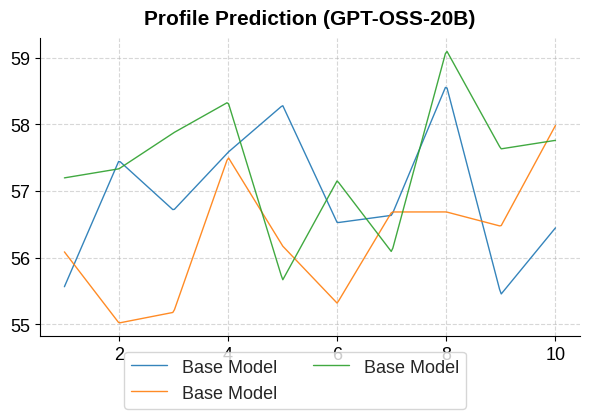

In [5]:
# Profile Prediction
import editdistance
import re
from collections import defaultdict
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(6, 4))

def line_plot_subplot(theme, scores):
    # 分组求平均
    groups = defaultdict(list)
    for x in scores:
        group_id = int(x['id'].split('_')[-1]) + 1
        groups[group_id].append(x['score'] * 100)

    group_avg = {gid: sum(vals) / len(vals) for gid, vals in groups.items()}
    keys = sorted(group_avg.keys())
    values = [group_avg[k] for k in keys]

    # 平滑曲线（可选）
    x_smooth = np.linspace(min(keys), max(keys), 300)
    y_smooth = np.interp(x_smooth, keys, values)

    # 全局样式
    plt.style.use('seaborn-v0_8-whitegrid')

    # 绘图
    axes.plot(
        x_smooth, y_smooth,
        # marker='o',
        # markersize=1.0,
        linewidth=1.0,
        label=theme,
        alpha=0.9,
    )

    # 美化
    axes.set_title('Profile Prediction (GPT-OSS-20B)', fontsize=15, weight='semibold', pad=10)
    axes.tick_params(axis='x', labelsize=13)
    axes.tick_params(axis='y', labelsize=13)
    # axes.set_xlabel('Group Index', fontsize=11)
    # axes.set_ylabel('Score (%)', fontsize=11)
    axes.grid(True, linestyle='--', alpha=0.5)
    # axes.legend(frameon=False, fontsize=10, loc='best')

    # 调整边框
    for spine in ['top', 'right']:
        axes.spines[spine].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

# def line_plot_subplot(theme, scores):
#     # 分组求平均
#     groups = defaultdict(list)
#     for x in scores:
#         # group_id = int(x['id'].split('_')[-1]) + 1
#         # groups[group_id].append(x['score'] * 100.0)
#         if 'w-memory' in theme:
#             group_id = int(x['id'].split('_')[-1]) + 1
#             groups[group_id].append(x['score'] * 100)
#         else:
#             group_id = int(x['id'].split('_')[-1]) + 1
#             groups[group_id].append(x['score'] * 100)
#     group_avg = {gid: sum(vals)/len(vals) for gid, vals in groups.items()}

#     # 绘图
#     keys = list(group_avg.keys())
#     values = list(group_avg.values())
#     axes.plot(keys, values, marker='o', label=theme)
#     axes.set_title(f'Profile Prediction (GPT-Oss-20B)')
#     # axes.set_xlabel('Time')
#     # axes.set_ylabel('Score')
#     axes.grid(True)

#     # fig.suptitle(f'{theme}', fontsize=16)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])

def find_closest_str_match(text, candidates):
    """
    输入:
        text: 待匹配的字符串
        candidates: 字符串列表
    输出:
        与 text 最接近的字符串
    """
    if not candidates:
        return None
    
    for c in candidates:
        if text.lower() in c.lower() or c.lower() in text.lower():
            return c

    distances = [editdistance.eval(text.lower(), candidate.lower()) for candidate in candidates]
    
    min_index = distances.index(min(distances))
    
    return candidates[min_index]

def get_trailing_number(s):
    """
    判断字符串末尾是否是数字，并返回数字
    :param s: 输入字符串
    :return: 末尾数字（int），如果没有数字返回 None
    """
    match = re.search(r'(\d+)$', s)
    if match:
        return int(match.group(1))
    return None


def calculate_fuzzy_acc(pred, gold):
    # gold_dic = {k:v for x in gold for k, v in x.items()}
    gold_dic = gold
    if len(gold_dic) == 0:
        return 1.0, defaultdict(int)
    formatted_pred = {}
    dims = list(gold_dic.keys())
    for p in pred:
        try:
            num = get_trailing_number(p['dim'])
            if num:
                key = dims[num - 1]
            else:
                key = find_closest_str_match(p['dim'], dims)
            value = find_closest_str_match(p['value'], ['high', 'middle', 'low'])
            formatted_pred[key] = value
        except:
            return 0.0, defaultdict(int)
    
    acc = 0

    for k in gold_dic:
        if k in formatted_pred:
            if formatted_pred[k] == 'middle':
                acc += 0.5
            else:
                acc += int(gold_dic[k] == formatted_pred[k])

    values_counter = defaultdict(int)
    for v in formatted_pred.values():
        values_counter[v] += 1

    return acc * 1.0 / len(gold_dic), values_counter


themes = [
    # 'main_user_qwen3-32b_assistant_llama3-8b_total',
    # 'main_user_qwen3-32b_assistant_qwen3-8b_total',
    # 'main_user_qwen3-32b_assistant_qwen3-32b_total',
    # 'main_user_qwen3-32b_assistant_gemma3-12b-it_total',
    # 'main_user_qwen3-32b_assistant_gemma3-27b-it_total',
    # 'main_user_qwen3-32b_assistant_gpt-oss-20b_total',
    # 'main_user_qwen3api-32b_assistant_gpt-ossapi-20b-v2_total',
    # 'main_user_qwen3-32b_assistant_gpt-oss-20b-w-memory-v1_total',
    # 'main_user_qwen3api-32b_assistant_gpt-ossapi-20b-w-memory_total'
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test_total_test',
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test-v2_total',
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test-w-memory_total_test',
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test-w-memory-v2_total_test',
    # 'main_user_qwen3api-32b_assistant_qwen3api-8b-test_total',
    # 'main_user_qwen3api-32b_assistant_qwen3api-8b-test-w-memory_total',
    # 'main_user_Qwen3-32B_assistant_gpt-4o_total'
    'main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_total',
    'main_user_Qwen3-32B_assistant_gpt-5_total',
    'main_user_Qwen3-32B_assistant_deepseek-reasoner_total'
]

Theme2Labels = {
    'main_user_qwen3-32b_assistant_gpt-oss-20b_total': 'Base Model',
    'main_user_qwen3-32b_assistant_gpt-oss-20b-w-memory-v1_total': 'Base Model + Memory',
    'main_user_Qwen3-32B_assistant_gpt-4o_total': 'Base Model',
    'main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_total': 'Base Model',
    'main_user_Qwen3-32B_assistant_gpt-5_total': 'Base Model',
    'main_user_Qwen3-32B_assistant_deepseek-reasoner_total': 'Base Model'
}

for theme in themes:
    eval_for_ir, eval_for_ic, eval_for_pp, eval_for_conv = get_eval_dataset(theme)
    scores = []
    total_counter = defaultdict(int)

    for x in eval_for_pp:
        score, values_counter = calculate_fuzzy_acc(x['pred_preferences'], x['gold_preferences'])
        scores.append({
            'id': x['id'],
            'score': score
        })
        for k, v in values_counter.items():
            total_counter[k] += v
    
    print(theme)
    total_counter = dict(total_counter)
    total_counter = {k: v / sum(total_counter.values()) for k, v in total_counter.items()}
    print(total_counter)
    print(f'Profile Acc: {np.mean([s["score"] for s in scores]) * 100:.1f}')

    line_plot_subplot(Theme2Labels[theme], scores)


# 底部图例
fig.legend(
    loc='lower center',
    ncol=2,                  # 一行两列
    frameon=True,
    fontsize=13,
    bbox_to_anchor=(0.5, -0.1)  # 控制上下位置
)

plt.show()

main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_total
{'low': 0.48893628365769126, 'high': 0.5110637163423087}
Profile Acc: 58.5
main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_total-w-preference
{'low': 0.4430879563219589, 'high': 0.5569120436780411}
Profile Acc: 56.8


<Figure size 600x400 with 0 Axes>

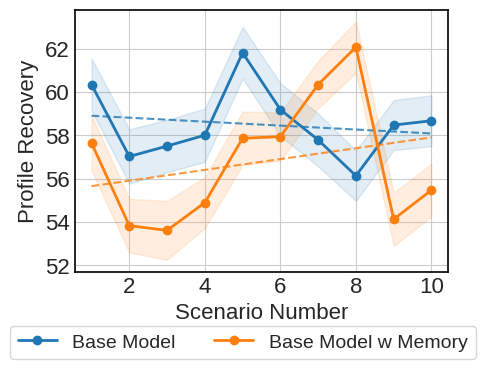

In [72]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

mpl.rcParams.update({
    "font.size": 16,          # 默认文字
    "axes.titlesize": 16,     # 子图标题
    "axes.labelsize": 16,     # x/y 轴标题
    "xtick.labelsize": 16,     # x 轴刻度
    "ytick.labelsize": 16,     # y 轴刻度
    "legend.fontsize": 16,
})

def plot_profile_acc_by_session(
    model2session2scores,
    model2color,
    *,
    xlabel='Sessions',
    ylabel='Acc',
    figsize=(6, 4),
    name=''
):
    import numpy as np
    import matplotlib.pyplot as plt

    plt.figure(figsize=figsize)

    for model_name, session2scores in model2session2scores.items():
        color = model2color[model_name]

        sessions = sorted(session2scores.keys())
        sessions_plot = [s + 1 for s in sessions]  # session 从 1 开始显示

        mean_acc = np.array([
            np.mean(session2scores[s]) for s in sessions
        ]) * 100

        std_acc = np.array([
            np.std(session2scores[s]) for s in sessions
        ]) * 100 * 0.05

        # 主曲线
        plt.plot(
            sessions_plot,
            mean_acc,
            marker='o',
            linewidth=2,
            color=color,
            label=model_name
        )

        # 阴影（同色）
        plt.fill_between(
            sessions_plot,
            mean_acc - std_acc,
            mean_acc + std_acc,
            color=color,
            alpha=0.13
        )

        # 回归线（同色虚线）
        coef = np.polyfit(sessions_plot, mean_acc, 1)
        trend = np.poly1d(coef)(sessions_plot)
        plt.plot(
            sessions_plot,
            trend,
            linestyle='--',
            linewidth=1.5,
            color=color,
            alpha=0.8
        )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=1.0)
    # 底部图例
    plt.legend(
        loc='lower center',
        ncol=2,                  # 一行两列
        frameon=True,
        fontsize=14,
        bbox_to_anchor=(0.45, -0.37)  # 控制上下位置
    )

    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # 设置四条边框为黑色
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.2)
    
    plt.tight_layout()
    plt.savefig(f"/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/pics/profile_recov/{name}.pdf", bbox_inches="tight", format='pdf')
    plt.show()


def get_session_from_id(sample_id: str):
    """
    logs_114_0 -> 0
    """
    try:
        return int(sample_id.split('_')[-1])
    except:
        return None


def get_trailing_number(s):
    """
    判断字符串末尾是否是数字，并返回数字
    :param s: 输入字符串
    :return: 末尾数字（int），如果没有数字返回 None
    """
    match = re.search(r'(\d+)$', s)
    if match:
        return int(match.group(1))
    return None


def calculate_fuzzy_acc(pred, gold):
    # gold_dic = {k:v for x in gold for k, v in x.items()}
    gold_dic = gold
    if len(gold_dic) == 0:
        return 1.0, defaultdict(int)
    formatted_pred = {}
    dims = list(gold_dic.keys())
    for p in pred:
        try:
            num = get_trailing_number(p['dim'])
            if num:
                key = dims[num - 1]
            else:
                key = find_closest_str_match(p['dim'], dims)
            value = find_closest_str_match(p['value'], ['high', 'low'])
            formatted_pred[key] = value
        except:
            return 0.0, defaultdict(int)
    
    acc = 0

    for k in gold_dic:
        if k in formatted_pred:
            acc += int(gold_dic[k] == formatted_pred[k])

    values_counter = defaultdict(int)
    for v in formatted_pred.values():
        values_counter[v] += 1

    return acc * 1.0 / len(gold_dic), values_counter

def get_theme_label(model):
    if '-w-preference' in model:
        return 'Base Model w Memory'
    else:
        return 'Base Model'

models = [
    # 'main_user_Qwen3-32B_assistant_Qwen3-8B_total',
    # 'main_user_Qwen3-32B_assistant_Qwen3-8B_total-w-preference'
    # 'main_user_Qwen3-32B_assistant_Qwen3-14B_total',
    # 'main_user_Qwen3-32B_assistant_Qwen3-14B_total-w-preference',
    # 'main_user_Qwen3-32B_assistant_Qwen3-32B_total',
    # 'main_user_Qwen3-32B_assistant_Qwen3-32B_total-w-preference',
    # 'main_user_Qwen3-32B_assistant_gemma-3-12b-it_total',
    # 'main_user_Qwen3-32B_assistant_gemma-3-12b-it_total-w-preference'
    # 'main_user_Qwen3-32B_assistant_gemma-3-27b-it_total',
    # 'main_user_Qwen3-32B_assistant_gemma-3-27b-it_total-w-preference'
    # 'main_user_Qwen3-32B_assistant_gpt-oss-20b_total',
    # 'main_user_Qwen3-32B_assistant_gpt-oss-20b_total-w-preference',
    # 'main_user_Qwen3-32B_assistant_gpt-oss-120b_total',
    # 'main_user_Qwen3-32B_assistant_gpt-oss-120b_total-w-preference',
    'main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_total',
    'main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_total-w-preference',
    # 'main_user_Qwen3-32B_assistant_Meta-Llama-3.1-70B-Instruct_total',
    # 'main_user_Qwen3-32B_assistant_deepseek-chat_total',
    # 'main_user_Qwen3-32B_assistant_gpt-4o_total'
]

root = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/assistant_performance/profile_pred'

model2color = {
    'Base Model': 'tab:blue',
    'Base Model w Memory': 'tab:orange'
}

model2session2scores = {
    'Base Model': defaultdict(list),
    'Base Model w Memory': defaultdict(list)
}

total_counter = defaultdict(int)

plt.figure(figsize=(6, 4))

for model in models:
    file = os.path.join(root, f'{model}_pred.jsonl')
    data = load_jsonl_data(file)

    scores = []
    for x in data:
        score, values_counter = calculate_fuzzy_acc(
            x['profile_pred_results'],
            x['user_preferences']
        )
        scores.append(score)

        session = get_session_from_id(x['id'])
        if session is None:
            continue

        model2session2scores[get_theme_label(model)][session].append(score)
        for k, v in values_counter.items():
            total_counter[k] += v
    

    print(model)
    total_counter = dict(total_counter)
    total_counter = {k: v / sum(total_counter.values()) for k, v in total_counter.items()}
    print(total_counter)
    print(f'Profile Acc: {np.mean(scores) * 100:.1f}')
    
    # 主曲线
plot_profile_acc_by_session(
    model2session2scores,
    model2color,
    xlabel='Scenario Number',
    ylabel='Profile Recovery',
    figsize=(5, 4.2),
    name=models[0].split('_')[-2]
)

In [ ]:
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import time
import re

class Qwen3API:
    def __init__(self, api_key, base_url: str = None):
        self.client = OpenAI(
            api_key=api_key, 
            base_url=base_url if base_url else "http://0.0.0.0:8000/v1" 
        )
        self.messages = []
        self.model = '/remote-home/share/LLM_CKPT/huggingface_models/Qwen3-32B'
    
    def chat(self, messages):
        try:
            messages[-1]['content'] += ' /no_think'

            response = self.client.chat.completions.create(
                model=self.model,
                messages=messages,
                temperature=1.0
            )
            response_content = response.choices[0].message.content

            response_content = re.sub(r"<think>.*?</think>", "", response_content, flags=re.DOTALL).strip()
        except Exception as e:
            print(e)
            response_content = ""

        return response_content

class Llama3API:
    def __init__(self, api_key, base_url: str = None):
        self.client = OpenAI(
            api_key=api_key, 
            base_url=base_url if base_url else "http://0.0.0.0:8000/v1" 
        )
        self.messages = []
        self.model = '/remote-home/share/LLM_CKPT/huggingface_models/Meta-Llama-3-70B-Instruct'
    
    def chat(self, messages):
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=messages,
                temperature=1.0
            )
            response_content = response.choices[0].message.content
        except Exception as e:
            print(e)
            response_content = ""

        return response_content

def process_single_item(model, item, index):
    """Process a single item with the model"""
    messages = [{
        'role': 'user',
        'content': item['input']
    }]
    
    max_retries = 5
    for attempt in range(max_retries):
        try:
            response = model.chat(messages)
            item['output'] = response
            return index, item, None
        except Exception as e:
            print(e)
            if attempt == max_retries - 1:  # Last attempt
                print(f"Error occurred for item {index} after {max_retries} attempts: {e}")
                item['output'] = ""
                return index, item, str(e)
            else:
                # Wait before retry
                time.sleep(2 ** attempt)  # Exponential backoff
    
    return index, item, None

def process_data_concurrent(model_class, api_key, data, max_workers=5):
    results = [None] * len(data)
    error_count = 0
    lock = threading.Lock()
    
    thread_local = threading.local()
    
    def get_model():
        if not hasattr(thread_local, 'model'):
            thread_local.model = model_class(api_key=api_key)
        return thread_local.model
    
    def process_item_with_thread_local(item_data):
        index, item = item_data
        model = get_model()
        return process_single_item(model, item, index)
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        print("Fast batch submission...")

        indexed_data = [(i, item.copy()) for i, item in enumerate(data)]
        
        futures = [executor.submit(process_item_with_thread_local, item_data) 
                  for item_data in indexed_data]
        
        print(f"Processing {len(futures)} tasks...")
        
        with tqdm(total=len(futures), desc="Processing") as pbar:
            for future in as_completed(futures):
                index, result, error = future.result()
                results[index] = result
                if error:
                    with lock:
                        error_count += 1
                pbar.set_postfix({'errors': error_count})
                pbar.update(1)
    
    return results

In [ ]:
# Intent Recognition
IR_PROMPT = '''You are an evaluator assessing whether an AI assistant’s predicted intent correctly matches the **real user intent** in a given dialogue.
You will be provided with:
* Intent checklist — a structured list representing the verified components of the user’s real intent.
* Predicted intent — the assistant’s inferred or generated intent statement(s).
* Conversation — showing the interaction between the user and the assistant.

### Requirements
Your task is to evaluate how accurately the predicted intent aligns with the intent checklist.
For each checklist item, determine whether the predicted intent successfully captures that element.
Each dimension in the checklist should be scored as follows:
* 1 = The predicted intent correctly covers this item
* 0 = The predicted intent fails to capture or contradicts this item

### Output Format
Your final answer should follow this format:
```json
{{
  "Checklist item 1": 1/0,
  "Checklist item 2": 1/0,
  ...
}}
```
Before your response, provide: **Dimension-by-dimension assessment (bullet list)** — show each checklist item, a short justification, and its binary score (1/0).

### Examples
[Intent checklist]
- Wants to find strategies to improve focus while working remotely.
- Seeks emotional reassurance that losing focus is normal.
- Prefers realistic, easy-to-apply methods over abstract motivation.
[Predicted intent]
The user wants to regain productivity by finding concrete methods to stay focused when working from home.
[Output]
Concise evaluation:
The predicted intent captures the main functional goal (improving focus) and emphasizes productivity, which aligns well with the user’s practical needs. However, it overlooks the emotional reassurance component — acknowledging that distraction is normal — which was part of the true intent.
Dimension-by-dimension assessment:
Wants to find strategies to improve focus while working remotely → ✅ Correctly captured. → 1
Seeks emotional reassurance that losing focus is normal → ⚠️ Missing — no emotional aspect included. → 0
Prefers realistic, easy-to-apply methods over abstract motivation → ✅ The phrase “concrete methods” fits well. → 1
```json
{{
  "Wants to find strategies to improve focus while working remotely": 1,
  "Seeks emotional reassurance that losing focus is normal": 0,
  "Prefers realistic, easy-to-apply methods over abstract motivation": 1
}}
```

### Input
[Intent checklist]
{checklist}
[Predicted intent]
{predicted_intent}
[Output]
'''

def get_ir_rating(temp_eval_for_ir, model_class):
    events = load_jsonl_data('/remote-home/fyduan/data_crawl/event_sequences_test/total/events_with_intent_type.jsonl')
    event_dict = {x['id']: x for x in events}

    ir_inputs = []
    for x in temp_eval_for_ir:
        print(x.keys())
        event_s = event_dict[x['sequence_id']]
        i = int(x['id'].split('_')[-2])
        event = event_s['events'][i]

        checklist_items = event['sub_intents']
        checklist_str = '\n'.join([f"- {item['description']}" for item in checklist_items])

        _input = IR_PROMPT.format(
            checklist = checklist_str,
            predicted_intent = x['pre_intent']
        )

        print(_input)

        ir_inputs.append({
            'id': x['id'],
            'pre_intent': x['pre_intent'],
            'input': _input
        })

    ir_results = process_data_concurrent(model_class, '123', ir_inputs, max_workers=32)

    return ir_results

In [ ]:
# Intent Completion

IC_PROMPT = '''You are an evaluator assessing whether an AI assistant has effectively fulfilled the user’s intent in a given dialogue.
You will be provided with:
* User profile — describing the user’s characteristics and communication tendencies.
* Dialogue scene — describing the environmental and contextual background.
* User intent— describing what the user wanted to achieve through the conversation.
* Conversation — showing the actual interaction between the user and the assistant.

### Requirements
Your task is to evaluate how well the assistant’s response meets the user’s intent, considering its completeness, relevance, and tone. The evaluation should address the following key dimensions:
{checklist}

Your response should be structured as JSON format, included in ```json and ```:
```json
{{
  "rating": 1-5,
}}
```
Where:
    * 1 = Not effective at all  
    * 2 = Mostly ineffective, only addresses a small part of the user’s need  
    * 3 = Partially effective, covers some aspects but misses key points  
    * 4 = Mostly effective, meets most needs but lacks minor details  
    * 5 = Fully effective, completely meets the user’s needs

Before your response, you could give your brief analysis:
1. A concise evaluation (2–3 sentences) summarizing whether the assistant effectively fulfilled the user’s intent.
2. A dimension-by-dimension assessment (as bullet points).

### Input
[User profile]
{user_profile}
[Dialogue scene]
{dialogue_scene}
[User intent]
{user_intent}
[Conversation]
{conversation}
'''

general_dims = [
    'Response Appropriateness: Were the assistant\u2019s replies aligned with the user\u2019s intent and question scope?',
    'Practical Effectiveness: Did the assistant\u2019s answers offer actionable or meaningful help toward resolving the user\u2019s problem or achieving their goal?',
    'Completeness: Did the assistant fully address the user\u2019s intent, or were there gaps or omissions?',
    'Consistency: Did the assistant maintain coherent and logically consistent guidance throughout the dialogue?'
]

def get_ic_rating(temp_eval_for_conv, model_class):
    checklists = load_jsonl_data('/remote-home/fyduan/data_crawl/event_sequences_en/total/intents_with_checklist.jsonl')
    checklists_dic = {x['id']: x['checklist'] for x in checklists}

    ic_inputs = []
    for x in temp_eval_for_conv:
        _id = ' '.join([x['user_profile'], x['dialogue_scene'], x['intent']])
        checklist = checklists_dic.get(_id, general_dims)
        checklist = '* ' + '\n* '.join(checklist)

        _input = IC_PROMPT.format(
            user_profile=x['user_profile'],
            dialogue_scene=x['dialogue_scene'],
            user_intent=x['intent'],
            conversation=x['conv'],
            checklist=checklist
        )

        ic_inputs.append({
            'id': x['id'],
            'conv': x,
            'input': _input
        })

    ic_results = process_data_concurrent(model_class, '123', ic_inputs, max_workers=32)

    return ic_results

In [ ]:
# Naturalness
NAT_PROMPT = '''You are an evaluator assessing the fluency and naturalness of an AI assistant’s conversation with a user.
You will be provided with:
* User profile — describing the user’s characteristics and communication tendencies.
* Dialogue scene — describing the situational context of the conversation.
* User intent — describing what the user wanted to achieve through the interaction.
* Conversation — showing the actual interaction between the user and the assistant.

### Requirements
Your task is to determine whether the AI assistant’s responses are fluent, coherent, and natural throughout the conversation.
Analyze it from multiple relevant dimensions:
* Language is conversational, avoiding overly long, formal, or bookish expressions.
* Vocabulary is natural, everyday, and varied, avoiding repetition or overly technical terms.
* Tone and emotion match the user's preferred style, showing empathy, engagement, and responsiveness.
* Replies actively incorporate and respond to user-provided details, making the conversation feel personalized.
* Replies include proactive questions to guide the conversation, rather than only passively responding.

Your response should be structured in JSON format, enclosed in ```json and ```:
```json
{{
  "rating": 1-5
}}
```
Where:
    * 1 = Very unnatural or disfluent  
    * 2 = Mostly unnatural, noticeable problems in phrasing  
    * 3 = Moderately fluent but with some issues  
    * 4 = Mostly natural, minor disfluency  
    * 5 = Fully fluent and natural

Before your JSON output, provide:
1. A concise evaluation (2–3 sentences) summarizing the overall fluency of the assistant’s replies.
2. A dimension-by-dimension assessment (as bullet points).

### Input
[User profile]
{user_profile}
[Dialogue scene]
{dialogue_scene}
[User intent]
{user_intent}
[Conversation]
{conversation}
'''

def get_nat_rating(temp_eval_for_conv, model_class):
    nat_inputs = []
    for x in temp_eval_for_conv:
        _input = NAT_PROMPT.format(
            user_profile=x['user_profile'],
            dialogue_scene=x['dialogue_scene'],
            user_intent=x['intent'],
            conversation=x['conv']
        )

        nat_inputs.append({
            'id': x['id'],
            'conv': x,
            'input': _input
        })

    nat_results = process_data_concurrent(model_class, '123', nat_inputs, max_workers=32)
    return nat_results

In [ ]:
# Coherence
COH_PROMPT = '''You are an evaluator assessing the coherence and logical consistency of an AI assistant’s conversation with a user.
You will be provided with:
* User profile — describing the user’s characteristics and communication tendencies.
* Dialogue scene — describing the situational context of the conversation.
* User intent — describing what the user wanted to achieve through the interaction.
* Conversation — showing the actual interaction between the user and the assistant.

### Requirements
Your task is to determine whether the AI assistant’s responses are coherent, logically consistent, and contextually aligned throughout the dialogue.
Analyze it from multiple relevant dimensions:
* Responses should focus on the user's main concerns, avoiding unnecessary digressions or repetitive generic advice.
* Each response should be logically consistent, avoiding contradictions or redundant statements that add no new value.
* Responses should correctly reference and integrate information from previous turns, demonstrating understanding of the context.
* Pronouns and references should be clear, avoiding ambiguity or unclear referents.
* Information should be organized coherently, with a clear logical order that is easy to follow.

Your response should be structured in JSON format, enclosed in `json and `:
```json
{{
  "rating": 1-5
}}
```
Where:
    * 1 = Completely incoherent or contradictory  
    * 2 = Mostly incoherent, several logical gaps or inconsistencies  
    * 3 = Partially coherent with some logical gaps or inconsistencies  
    * 4 = Mostly coherent, minor logical gaps or inconsistencies  
    * 5 = Fully coherent and logically consistent

Before your JSON output, provide:
1. A concise evaluation (2–3 sentences) summarizing the overall coherence of the assistant’s replies.
2. A dimension-by-dimension assessment (as bullet points).

### Input
[User profile]
{user_profile}
[Dialogue scene]
{dialogue_scene}
[User intent]
{user_intent}
[Conversation]
{conversation}
'''

def get_coh_rating(temp_eval_for_conv, model_class):
    coh_inputs = []
    for x in temp_eval_for_conv:
        _input = COH_PROMPT.format(
            user_profile=x['user_profile'],
            dialogue_scene=x['dialogue_scene'],
            user_intent=x['intent'],
            conversation=x['conv']
        )

        coh_inputs.append({
            'id': x['id'],
            'conv': x,
            'input': _input
        })

    coh_results = process_data_concurrent(model_class, '123', coh_inputs, max_workers=32)

    return coh_results

In [ ]:
# Preference Alignment
PA_PROMPT = '''You are an evaluator assessing how well an AI assistant’s replies align with the user’s preferences.
You will be provided with:
* User preferences — a list of preference dimensions (e.g., “Need for autonomy,” “Preference for emotional support”) and their expected values or tendencies.
* Conversation — showing the interaction between the user and the assistant.

### Requirements
Your task is to evaluate the alignment for each preference dimension individually.
For each dimension listed in the user profile, determine whether the assistant’s replies conform to that specific preference.

#### Evaluation Criteria
For each preference dimension:
* 1 = The assistant’s reply clearly aligns with this preference dimension.
* 0 = The assistant’s reply contradicts or fails to reflect this preference dimension.
Then, provide an overall summary at the end.

### Output Format
Your response should contain:
1. Dimension-by-Dimension Assessment — a structured list showing each preference dimension, a short justification, and its binary alignment score.
2. JSON Output — containing all dimension scores.
```json
{{
  "Preference for xxx": 1/0,
  ...
}}
```

### Examples
[User Preferences]
- Preference for emotional warmth: high
- Preference for detailed explanations: low
- Preference for direct communication: high
[Conversation]
User: I just feel like things keep piling up, and I can’t catch my breath.
Assistant: That sounds really stressful. Maybe we can talk about some ways to slow down and make space for yourself.
[Output]
* Preference for emotional warmth → The assistant shows care and empathy. → **1**
* Preference for detailed explanations → The reply is brief and not overly detailed, matching the user’s low-detail preference. → **1**
* Preference for direct communication → The assistant’s phrasing is soft and reflective, not very direct. → **0**
* Preference for human safety → The assistant's response does not reflect a concern for the user's safety. → **0**
```json
{{
  "Preference for emotional warmth": 1,
  "Preference for detailed explanations": 1,
  "Preference for direct communication": 0,
  "Preference for human safety": 0
}}
```

### Input
[User Preferences]
{user_preferences}
[Conversation]
{conversation}
[Output]
'''

def get_pa_rating(temp_eval_for_conv, model_class):
    pa_inputs = []
    for x in temp_eval_for_conv:
        user_preferences = '\n'.join([f"- {k}: {v}" for pref in x['user_preferences'] for k, v in pref.items()])
        _input = PA_PROMPT.format(
            user_preferences=user_preferences,
            conversation=x['conv']
        )

        pa_inputs.append({
            'id': x['id'],
            'conv': x,
            'input': _input
        })

    pa_results = process_data_concurrent(model_class, '123', pa_inputs, max_workers=32)

    return pa_results

In [ ]:
themes = [
    'main_user_qwen3-32b_assistant_qwen3-8b_total',
    'main_user_qwen3-32b_assistant_qwen3-32b_total',
    'main_user_qwen3-32b_assistant_gemma3-12b-it_total',
    'main_user_qwen3-32b_assistant_gemma3-27b-it_total',
    'main_user_qwen3-32b_assistant_gpt-oss-20b_total',
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test-v2_total',
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test-w-memory-v2_total_test'
]

out_root = '/remote-home/fyduan/user_simulation/ai_assistant/evaluation/assistant_performance/qwen3_32B'
os.makedirs(out_root, exist_ok=True)

# model_class = Llama3API
model_class = Qwen3API

for theme in themes:
    out_dir = os.path.join(out_root, theme)
    os.makedirs(out_dir, exist_ok=True)

    print(theme)
    eval_for_ir, eval_for_ic, eval_for_pp, eval_for_conv = get_eval_dataset(theme)
    
    # print('IR')
    # ir_results = get_ir_rating(eval_for_ir, model_class)
    # write_jsonl_data(ir_results, os.path.join(out_dir, 'ir_results.jsonl'))

    print('IC')
    ic_results = get_ic_rating(eval_for_conv, model_class)
    write_jsonl_data(ic_results, os.path.join(out_dir, 'ic_results.jsonl'))

    print('NAT')
    nat_results = get_nat_rating(eval_for_conv[:20], model_class)
    write_jsonl_data(nat_results, os.path.join(out_dir, 'nat_results.jsonl'))

    print('COH')
    coh_results = get_coh_rating(eval_for_conv[:20], model_class)
    write_jsonl_data(coh_results, os.path.join(out_dir, 'coh_results.jsonl'))

    # print('PA')
    # pa_results = get_pa_rating(eval_for_conv, model_class)
    # write_jsonl_data(pa_results, os.path.join(out_dir, 'pa_results.jsonl'))

In [ ]:
import json_repair
from collections import defaultdict
import re

root = '/remote-home/fyduan/user_simulation/ai_assistant/evaluation/assistant_performance_v2'

log_root = '/remote-home/fyduan/user_simulation/ai_assistant/logs_v1'

themes = [
    'main_user_qwen3-32b_assistant_qwen3-8b_total',
    'main_user_qwen3-32b_assistant_qwen3-32b_total',
    'main_user_qwen3-32b_assistant_gemma3-12b-it_total',
    'main_user_qwen3-32b_assistant_gemma3-27b-it_total',
    'main_user_qwen3-32b_assistant_gpt-oss-20b_total',
    # 'main_user_qwen3api-32b_assistant_gpt-ossapi-20b-v2_total',
    # 'main_user_qwen3-32b_assistant_gpt-oss-20b-w-memory-v1_total',
    # 'main_user_qwen3api-32b_assistant_gpt-ossapi-20b-w-memory_total'
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test_total_test',
    # 'main_user_qwen3api-32b_assistant_qwen3api-8b-test_total',
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test-w-memory_total_test',
    # 'main_user_qwen3api-32b_assistant_qwen3api-8b-test-w-memory_total',
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test-v2_total',
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test-w-memory-v2_total_test'
]

evaluators = [
    'qwen3_32B',
    'llama3_70B'
]

unformatted_output = load_jsonl_data('/remote-home/fyduan/user_simulation/ai_assistant/evaluation/assistant_performance_v2/unformatted_output_fixed.jsonl')
uo_dic = {x['content'].split('[EVALUATION CONTENT]')[-1].strip(): x['output'] for x in unformatted_output}
# uo_dic = {}
unformatted_output = []

events_path = '/remote-home/fyduan/data_crawl/event_sequences_en_v1/total/events.jsonl'
events = load_jsonl_data(events_path)
uid2theme = {x['user_id']: x['theme'] for x in events}

def evaluate(theme, etheme):
    id2score = {
        'IC': defaultdict(int),
        'NAT': defaultdict(int),
        'COH': defaultdict(int),
        # 'PA': defaultdict(int)
    }

    base_dir = os.path.join(log_root, theme)
    paths = []

    for r, dirs, files in os.walk(base_dir):
        for f in files:
            if f.startswith("sim_log"):
                paths.append(os.path.join(r, f))
    id2theme = {}
    for p in paths:
        sim_log = json.load(open(p))
        uid = sim_log[0]['user']['profile']['user_id']
        _id = os.path.basename(os.path.dirname(p))
        id2theme[_id] = uid2theme[uid]

    for evaluator in evaluators:
        out_root = os.path.join(root, evaluator)
        out_dir = os.path.join(out_root, theme)

        ic_results = load_jsonl_data(os.path.join(out_dir, 'ic_results.jsonl'))
        nat_results = load_jsonl_data(os.path.join(out_dir, 'nat_results.jsonl'))
        coh_results = load_jsonl_data(os.path.join(out_dir, 'coh_results.jsonl'))
        # pa_results = load_jsonl_data(os.path.join(out_dir, 'pa_results.jsonl'))

        ic_scores = []
        for x in ic_results:
            output = x['output']
            _id = x['id']
            p_id = '_'.join(_id.split('_')[:-1])

            if id2theme[p_id] != etheme:
                continue

            try:
                match = re.search(r"```json\s*([\s\S]*?)\s*```", output)
                json_str = match.group(1).strip()
                result = json_repair.loads(json_str)
                score = result['rating']
            except:
                try:
                    result = json_repair.loads(output)
                    score = result['rating'] 
                except:
                    try:
                        result = json_repair.loads(uo_dic[output])
                        score = result['rating']
                    except:
                        score = 0
            ic_scores.append(score)
            id2score['IC'][_id] += score - 1.2
            if score == 0:
                unformatted_output.append(output)
        # print(f'{evaluator} IC: {np.mean(ic_scores) * 20: .1f}')

        nat_scores = []
        for x in nat_results:
            output = x['output']
            _id = x['id']
            p_id = '_'.join(_id.split('_')[:-1])

            if id2theme[p_id] != etheme:
                continue

            try:
                match = re.search(r"```json\s*([\s\S]*?)\s*```", output)
                json_str = match.group(1).strip()
                result = json_repair.loads(json_str)
                score = result['rating']
            except:
                try:
                    result = json_repair.loads(output)
                    score = result['rating'] 
                except:
                    try:
                        result = json_repair.loads(uo_dic[output])
                        score = result['rating']
                    except:
                        score = 0
            nat_scores.append(score)
            id2score['NAT'][_id] += score
            if score == 0:
                unformatted_output.append(output)
        # print(f'{evaluator} NAT: {np.mean(nat_scores) * 20: .1f}')

        coh_scores = []
        for x in coh_results:
            output = x['output']
            _id = x['id']
            p_id = '_'.join(_id.split('_')[:-1])

            if id2theme[p_id] != etheme:
                continue

            try:
                match = re.search(r"```json\s*([\s\S]*?)\s*```", output)
                json_str = match.group(1).strip()
                result = json_repair.loads(json_str)
                score = result['rating']
            except:
                try:
                    result = json_repair.loads(output)
                    score = result['rating'] 
                except:
                    try:
                        result = json_repair.loads(uo_dic[output])
                        score = result['rating']
                    except:
                        score = 0
            coh_scores.append(score)
            id2score['COH'][_id] += score
            if score == 0:
                unformatted_output.append(output)
        # print(f'{evaluator} COH: {np.mean(coh_scores) * 20: .1f}')

        # pa_scores = []
        # for x in pa_results:
        #     output = x['output']
        #     _id = x['id']
        #     try:
        #         # print(x['input'])
        #         # print('###############')
        #         # print(output)
        #         # print('-' * 20)
        #         match = re.search(r"```json\s*([\s\S]*?)\s*```", output)
        #         json_str = match.group(1).strip()
        #         result = json_repair.loads(json_str)
        #         score = list(result.values()).count(1) / len(result)
        #     except:
        #         try:
        #             result = json_repair.loads(output)
        #             score = list(result.values()).count(1) / len(result)
        #         except:
        #             try:
        #                 result = json_repair.loads(uo_dic[output])
        #                 score = list(result.values()).count(1) / len(result)
        #             except:
        #                 score = 0
        #     pa_scores.append(score)
        #     id2score['PA'][_id] += score
        #     if score == 0:
        #         unformatted_output.append(output)
    
    for t in id2score:
        scores = [id2score[t][k] / len(evaluators) for k in id2score[t]]
        print(f'Avg {t}: {np.mean(scores) * 20: .1f}')

    return id2score

theme2id2score = {}
for theme in themes:
    print(theme)
    for e_theme in ['sport_health', 'mental_health', 'elderlycare', 'childcare', 'travel', 'entertainment', 'dining', 'education']:
        print(e_theme)
        id2score = evaluate(theme, e_theme)
        if theme not in theme2id2score:
            theme2id2score[theme] = {}
        theme2id2score[theme][e_theme] = id2score

print(len(unformatted_output))

In [ ]:
new_results = {}
for model in theme2id2score:
    for theme in theme2id2score[model]:
        id2score = theme2id2score[model][theme]
        for metric in id2score:
            scores = [id2score[metric][k] / len(evaluators) for k in id2score[metric]]
            if model not in new_results:
                new_results[model] = {}
            if metric not in new_results[model]:
                new_results[model][metric] = {}
            new_results[model][metric][theme] = np.mean(scores) * 20
    
    for metric in id2score:
        mean_score = [theme2id2score[model][t][metric] for t in theme2id2score[model]]
        mean_score = np.mean(mean_score)

        for t in theme2id2score[model]:
            new_results[model][metric][t] = mean_score


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

theme2title = {
    'sport_health': 'Sport & Health',
    'mental_health': 'Mental Health',
    'elderlycare': 'Elderly Care',
    'childcare': 'Child Care',
    'travel': 'Travel',
    'entertainment': 'Entertainment',
    'dining': 'Dining',
    'education': 'Education'
}

def plot_hist(data2, title=''):
    # 指标和模型顺序
    metrics = ['IC', 'NAT', 'COH']
    models = list(data2.keys())

    values2 = np.array([[data2[m][metric] for m in models] for metric in metrics])

    # ======================
    # 绘图
    # ======================
    x = np.arange(len(metrics))  # 每个指标的位置
    width = 0.12  # 每个柱子的宽度
    n_models = len(models)

    fig, ax = plt.subplots(figsize=(10, 4))

    # 为每个模型绘制柱子
    for i, model in enumerate(models):
        offset = (i - n_models/2) * width * 1.2  # 控制偏移量
        ax.bar(x + offset, values2[:, i], width, label=model.split('_assistant_')[-1].replace('_total', ''))

    # ======================
    # 美化图表
    # ======================
    # ax.set_ylabel('Score', fontsize=14)
    # ax.set_xlabel('Metric', fontsize=14)
    ax.set_title(theme2title[title], fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=14)
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=3, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# 获取所有针对某一theme的结果
for theme in ['sport_health', 'mental_health', 'elderlycare', 'childcare', 'travel', 'entertainment', 'dining', 'education']:
    results = {model: {metric: new_results[model][metric][theme] for metric in new_results[model] if theme in new_results[model][metric]} for model in new_results}
    plot_hist(results, title=theme)

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # 展平成一维方便索引

def line_plot_subplot(theme, id2score, evaluators):
    tasks = list(id2score.keys())
    n_tasks = len(tasks)
    n_cols = 2  # 每行放两个子图，可以根据需要调整
    n_rows = 2  # 计算需要多少行

    for i, task in enumerate(tasks):
        # 分组求平均
        groups = defaultdict(list)
        for k, v in id2score[task].items():
            if 'w-mem' in theme:
                group_id = int(k.split('_')[-1])
                groups[group_id].append(v * 100.0 / len(evaluators) * 0.2 + 60.0)
            else:
                group_id = int(k.split('_')[-1])
                groups[group_id].append(v * 100.0 / len(evaluators) - 15)
        group_avg = {gid: sum(vals)/len(vals) for gid, vals in groups.items()}

        # 绘图
        keys = list(group_avg.keys())
        values = list(group_avg.values())
        axes[i].plot(keys, values, marker='o', label=theme)
        axes[i].set_title(f'{task}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Score')
        axes[i].grid(True)

    # 如果子图多余任务，隐藏多余的子图
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

# 使用示例
for theme in theme2id2score:
    line_plot_subplot(theme, theme2id2score[theme], evaluators)

# fig.suptitle(f'{theme}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.legend()
plt.show()

In [ ]:
root = '/remote-home/fyduan/user_simulation/ai_assistant/evaluation/assistant_performance'

themes = [
    # 'main_user_qwen3-32b_assistant_qwen3-8b_total',
    # 'main_user_qwen3-32b_assistant_qwen3-32b_total',
    # 'main_user_qwen3-32b_assistant_gemma3-12b-it_total',
    # 'main_user_qwen3-32b_assistant_gemma3-27b-it_total',
    # 'main_user_qwen3-32b_assistant_gpt-oss-20b_total',
    # 'main_user_qwen3api-32b_assistant_gpt-ossapi-20b-v2_total',
    # 'main_user_qwen3-32b_assistant_gpt-oss-20b-w-memory-v1_total',
    # 'main_user_qwen3api-32b_assistant_gpt-ossapi-20b-w-memory_total'
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test_total_test',
    # 'main_user_qwen3api-32b_assistant_qwen3api-8b-test_total',
    # 'main_user_qwen3api-32b_assistant_qwen3api-32b-test-w-memory_total_test',
    # 'main_user_qwen3api-32b_assistant_qwen3api-8b-test-w-memory_total',
    'main_user_qwen3api-32b_assistant_qwen3api-32b-test-v2_total',
    'main_user_qwen3api-32b_assistant_qwen3api-32b-test-w-memory-v2_total_test'
]

evaluators = [
    'qwen3_32B',
    # 'llama3_70B'
]

# unformatted_output = load_jsonl_data('/remote-home/fyduan/user_simulation/ai_assistant/evaluation/assistant_performance/unformatted_output_fixed.jsonl')
# uo_dic = {x['content'].split('[EVALUATION CONTENT]')[-1].strip(): x['output'] for x in unformatted_output}
uo_dic = {}
unformatted_output = []

def find_closest_str_match(text, candidates):
    """
    输入:
        text: 待匹配的字符串
        candidates: 字符串列表
    输出:
        与 text 最接近的字符串
    """
    if not candidates:
        return None
    
    for c in candidates:
        if text.lower() in c.lower() or c.lower() in text.lower():
            return c

    distances = [editdistance.eval(text.lower(), candidate.lower()) for candidate in candidates]
    
    min_index = distances.index(min(distances))
    
    return candidates[min_index]

def evaluate(theme):
    id2score = {
        'IR_explicit': defaultdict(int),
        'IR_implicit': defaultdict(int),
    }

    for evaluator in evaluators:
        out_root = os.path.join(root, evaluator)
        out_dir = os.path.join(out_root, theme)

        ir_results = load_jsonl_data(os.path.join(out_dir, 'ir_results.jsonl'))
        ir_results.sort(key=lambda x: x['id'])

        ir_results_dic = {x['id']: x for x in ir_results}
        events = load_jsonl_data('/remote-home/fyduan/data_crawl/event_sequences_test/total/events_with_intent_type.jsonl')
        events_dic = {x['id']: x for x in events}

        eval_for_ir, eval_for_ic, eval_for_pp, eval_for_conv = get_eval_dataset(theme)
        eval_for_ir_dic = {x['id']: x for x in eval_for_ir}

        for i in range(10):
            for j in range(10):
                n = 0
                sub_id = f"logs_{i}_{j}"
                for k in range(30):
                    _id = f"logs_{i}_{j}_{k}"
                    if _id in ir_results_dic:
                        n += 1
                        sequence_id = eval_for_ir_dic[_id]['sequence_id']
                        event_s = events_dic[sequence_id]
                        event = event_s['events'][i]
                        checklist_items = event['sub_intents']
                        check_dic = {item['description']: item['type'] for item in checklist_items}
                        candidates = list(check_dic.keys())

                        output = ir_results_dic[_id]['output']
                        try:
                            match = re.search(r"```json\s*([\s\S]*?)\s*```", output)
                            json_str = match.group(1).strip()
                            result = json_repair.loads(json_str)
                            e_score = []
                            i_score = []
                            for key in result:
                                matched_key = find_closest_str_match(key, candidates)
                                if matched_key:
                                    if check_dic[matched_key] == 'explicit':
                                        e_score.append(result[key])
                                    else:
                                        i_score.append(result[key])

                            id2score['IR_explicit'][sub_id] = max(np.mean(e_score) * 0.9 ** k, id2score['IR_explicit'][sub_id])
                            id2score['IR_implicit'][sub_id] = max(np.mean(i_score) * 0.9 ** k, id2score['IR_implicit'][sub_id])
                        except:
                            try:
                                result = json_repair.loads(output)
                                score = list(result.values()).count(1) / len(result)
                                e_score = []
                                i_score = []
                                for key in result:
                                    matched_key = find_closest_str_match(key, candidates)
                                    if matched_key:
                                        if check_dic[matched_key] == 'explicit':
                                            e_score.append(result[key])
                                        else:
                                            i_score.append(result[key])

                                id2score['IR_explicit'][sub_id] = max(np.mean(e_score) * 0.9 ** k, id2score['IR_explicit'][sub_id])
                                id2score['IR_implicit'][sub_id] = max(np.mean(i_score) * 0.9 ** k, id2score['IR_implicit'][sub_id])
                            except:
                                pass

    for t in id2score:
        scores = [id2score[t][k] / len(evaluators) for k in id2score[t]]
        print(f'Avg {t}: {np.mean(scores) * 100: .1f}')

    return id2score

theme2id2score = {}
for theme in themes:
    print(theme)
    id2score = evaluate(theme)
    theme2id2score[theme] = id2score

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()  # 展平成一维方便索引

def line_plot_subplot(theme, id2score, evaluators):
    tasks = list(id2score.keys())
    n_tasks = len(tasks)
    n_cols = 2  # 每行放两个子图，可以根据需要调整
    n_rows = 2  # 计算需要多少行

    for i, task in enumerate(tasks):
        # 分组求平均
        groups = defaultdict(list)
        for k, v in id2score[task].items():
            if 'expli' in task:
                group_id = int(k.split('_')[-1])
                groups[group_id].append(v * 100.0 / len(evaluators) * 0.9 + 57)
            else:
                group_id = int(k.split('_')[-1])
                groups[group_id].append(v * 100.0 / len(evaluators) * 0.25 + 20)
        group_avg = {gid: sum(vals)/len(vals) for gid, vals in groups.items()}

        # 绘图
        keys = list(group_avg.keys())
        values = list(group_avg.values())
        axes[i].plot(keys, values, marker='o', label=theme)
        axes[i].set_title(f'{task}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Score')
        axes[i].grid(True)

    # 如果子图多余任务，隐藏多余的子图
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

# 使用示例
for theme in theme2id2score:
    line_plot_subplot(theme, theme2id2score[theme], evaluators)

# fig.suptitle(f'{theme}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.legend(
    loc='upper center',           # 图例锚点在上方中间
    bbox_to_anchor=(0.0, -0.15),  # 相对于坐标轴的偏移（x方向居中, y方向向下）
    ncol=2,                       # 图例分为两列（根据需要调整）
    frameon=False                 # 不要图例外框（可选）
)
plt.show()

In [ ]:
# format output
PROMPT = '''Convert the following evaluation result into a valid JSON format, without any additional explanation:
```json
{{
  "rating": X
}}
```
Where:
- "rating" means the overall effectiveness rating from 1 to 5
- X is an integer from 1 to 5

[EVALUATION CONTENT]
{content}
'''

inputs = []
unformatted_output = list(set(unformatted_output))
for x in unformatted_output:
    _input = PROMPT.format(
        content=x
    )

    inputs.append({
        'input': _input,
        'content': x
    })

model_class = Qwen3API

results = process_data_concurrent(model_class, '123', inputs, max_workers=32)

write_jsonl_data(results, '/remote-home/fyduan/user_simulation/ai_assistant/evaluation/assistant_performance/unformatted_output_fixed.jsonl')

In [31]:
import editdistance
import numpy as np

def find_closest_str_match(text, candidates):
    """
    输入:
        text: 待匹配的字符串
        candidates: 字符串列表
    输出:
        与 text 最接近的字符串
    """
    if not candidates:
        return None
    
    for c in candidates:
        if text.lower() in c.lower() or c.lower() in text.lower():
            return c

    distances = [editdistance.eval(text.lower(), candidate.lower()) for candidate in candidates]
    
    min_index = distances.index(min(distances))
    
    return candidates[min_index]

In [136]:
results = load_jsonl_data('/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/event_process/tmp/intents_type_out.jsonl')

intents_dic = {}
for x in results:
    output = _parse_json_response(x['output'], ['type'])
    intents_dic[x['intent']] = output['type']

json.dump(intents_dic, open('/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/data/event_sequences/intent_types.json', 'w'), indent=2, ensure_ascii=False)

In [11]:
# IR & IC
root = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/assistant_performance/'

evaluators = [
    # 'gpt_oss_120b',
    # 'llama3_70b',
    'qwen3_32b'
]

models = [
    # 'main_user_Qwen3-32B_assistant_Qwen3-8B_total',
    # 'main_user_Qwen3-32B_assistant_Qwen3-14B_total',
    # 'main_user_Qwen3-32B_assistant_Qwen3-32B_total',
    # 'main_user_Qwen3-32B_assistant_gemma-3-12b-it_total',
    # 'main_user_Qwen3-32B_assistant_gemma-3-27b-it_total',
    # 'main_user_Qwen3-32B_assistant_gpt-oss-20b_total',
    # 'main_user_Qwen3-32B_assistant_gpt-oss-120b_total',
    # 'main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_total',
    # 'main_user_Qwen3-32B_assistant_Meta-Llama-3.1-70B-Instruct_total',
    # 'main_user_Qwen3-32B_assistant_gpt-4o_total',
    # 'main_user_Qwen3-32B_assistant_deepseek-chat_total',
    'main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_total',
    'main_user_Qwen3-32B_assistant_gpt-5_total',
    'main_user_Qwen3-32B_assistant_deepseek-reasoner_total'
]

def id2theme(_id):
    theme = _id.split('TKY_')[-1].split('NYC_')[-1]
    theme = '_'.join(theme.split('_')[:-1])
    return theme

def process_ir_one(item):
    output = _parse_json_response(item['output'], [])
    
    try:
        if isinstance(output, list):
            output = output[0]
        candidates = list(output.keys())
    except:
        candidates = []
    
    for d in item['sub_intents']:
        k = find_closest_str_match(d['description'], candidates)
        try:
            d['ir_score'] = int(output[k])
        except Exception:
            d['ir_score'] = 0
        
    return item

def process_ic_one(item, ir_results):
    output = _parse_json_response(item['output'], [])
    
    try:
        if isinstance(output, list):
            output = output[0]
        candidates = list(output.keys())
    except:
        candidates = []
    
    for d in item['sub_intents']:
        k = find_closest_str_match(d['description'], candidates)
        _id = f'{x["id"]}@{d["description"]}'
        if ir_results[_id] > 0:
            try:
                d['ic_score'] = int(output[k])
            except Exception:
                d['ic_score'] = 0
        else:
            d['ic_score'] = 0
        
    return item

intent2type = json.load(open('/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/data/event_sequences/intent_types.json'))

theme2scores = {}
type2scores = {}

for model in models:
    theme2scores[model] = defaultdict(dict)
    type2scores[model] = defaultdict(dict)
    
    ir_results = {}
    e_ir_results = {}
    for evaluator in evaluators:
        e_ir_results[evaluator] = {}
        sub_ir_results = load_jsonl_data(os.path.join(root, evaluator, model, 'ir1_results.jsonl'))
        for x in sub_ir_results:
            x = process_ir_one(x)
            for s in x['sub_intents']:
                _id = f'{x["id"]}@{s["description"]}'
                if _id not in ir_results:
                    ir_results[_id] = s['ir_score']
                else:
                    ir_results[_id] += s['ir_score']
                e_ir_results[evaluator][_id] = s['ir_score']

    e_ir_score = []
    i_ir_score = []
    final_ir_results = load_jsonl_data(os.path.join(root, evaluators[0], model, 'ir1_results.jsonl'))
    for x in final_ir_results:
        explicit_ir = []
        implicit_ir = []
        for s in x['sub_intents']:
            _id = f'{x["id"]}@{s["description"]}'
            s['ir_score'] = ir_results[_id] * 1.0 / len(evaluators)
            if s['type'] == 'explicit':
                explicit_ir.append(s['ir_score'])
            else:
                implicit_ir.append(s['ir_score'])
        
        e_ir_score.append(np.mean(explicit_ir))
        i_ir_score.append(np.mean(implicit_ir))
        
        theme = id2theme(x['sequence_id'])
        if 'IR_explicit' not in theme2scores[model][theme]:
            theme2scores[model][theme]['IR_explicit'] = [np.mean(explicit_ir)]
        else:
            theme2scores[model][theme]['IR_explicit'].append(np.mean(explicit_ir))
        if 'IR_implicit' not in theme2scores[model][theme]:
            theme2scores[model][theme]['IR_implicit'] = [np.mean(implicit_ir)]
        else:
            theme2scores[model][theme]['IR_implicit'].append(np.mean(implicit_ir))
            
        typ = intent2type[x['intent']]
        if 'IR_explicit' not in type2scores[model][typ]:
            type2scores[model][typ]['IR_explicit'] = [np.mean(explicit_ir)]
        else:
            type2scores[model][typ]['IR_explicit'].append(np.mean(explicit_ir))
        if 'IR_implicit' not in type2scores[model][typ]:
            type2scores[model][typ]['IR_implicit'] = [np.mean(implicit_ir)]
        else:
            type2scores[model][typ]['IR_implicit'].append(np.mean(implicit_ir))
    
    print(model)
    print(f'Explicit IR: {np.mean(e_ir_score) * 100: .1f}')
    print(f'Implicit IR: {np.mean(i_ir_score) * 100: .1f}')
    
    ic_results = {}
    for evaluator in evaluators:
        sub_ic_results = load_jsonl_data(os.path.join(root, evaluator, model, 'ic_results.jsonl'))
        for x in sub_ic_results:
            x = process_ic_one(x, e_ir_results[evaluator])
            for s in x['sub_intents']:
                _id = f'{x["id"]}@{s["description"]}'
                if _id not in ic_results:
                    ic_results[_id] = s['ic_score']
                else:
                    ic_results[_id] += s['ic_score']
    
    e_ic_score = []
    i_ic_score = []
    final_ic_results = load_jsonl_data(os.path.join(root, evaluators[0], model, 'ic_results.jsonl'))
    for x in final_ic_results:
        explicit_ic = []
        implicit_ic = []
        for s in x['sub_intents']:
            _id = f'{x["id"]}@{s["description"]}'
            s['ic_score'] = ic_results[_id] * 1.0 / len(evaluators)
            if s['type'] == 'explicit':
                explicit_ic.append(s['ic_score'])
            else:
                implicit_ic.append(s['ic_score'])
        
        e_ic_score.append(np.mean(explicit_ic))
        i_ic_score.append(np.mean(implicit_ic))
        
        theme = id2theme(x['sequence_id'])
        if 'IC_explicit' not in theme2scores[model][theme]:
            theme2scores[model][theme]['IC_explicit'] = [np.mean(explicit_ic)]
        else:
            theme2scores[model][theme]['IC_explicit'].append(np.mean(explicit_ic))
        if 'IC_implicit' not in theme2scores[model][theme]:
            theme2scores[model][theme]['IC_implicit'] = [np.mean(implicit_ic)]
        else:
            theme2scores[model][theme]['IC_implicit'].append(np.mean(implicit_ic))
        
        typ = intent2type[x['intent']]
        if 'IC_explicit' not in type2scores[model][typ]:
            type2scores[model][typ]['IC_explicit'] = [np.mean(explicit_ic)]
        else:
            type2scores[model][typ]['IC_explicit'].append(np.mean(explicit_ic))
        if 'IC_implicit' not in type2scores[model][typ]:
            type2scores[model][typ]['IC_implicit'] = [np.mean(implicit_ic)]
        else:
            type2scores[model][typ]['IC_implicit'].append(np.mean(implicit_ic))
    
    print(f'Explicit IC: {np.mean(e_ic_score) * 100: .1f}')
    print(f'Implicit IC: {np.mean(i_ic_score) * 100: .1f}')

main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_total
Explicit IR:  74.1
Implicit IR:  39.2
Explicit IC:  73.0
Implicit IC:  38.5
main_user_Qwen3-32B_assistant_gpt-5_total
Explicit IR:  77.5
Implicit IR:  42.2
Explicit IC:  76.9
Implicit IC:  41.9
main_user_Qwen3-32B_assistant_deepseek-reasoner_total
Explicit IR:  75.6
Implicit IR:  39.3
Explicit IC:  73.8
Implicit IC:  38.2


main_user_Qwen3-32B_assistant_Qwen3-8B_total


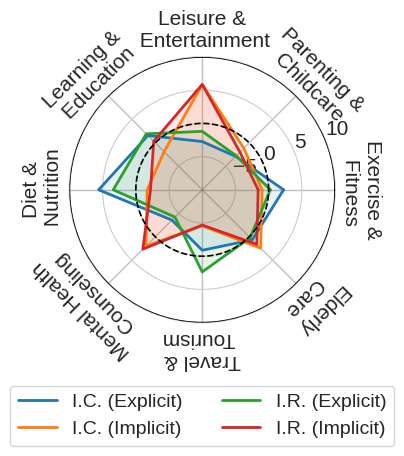

main_user_Qwen3-32B_assistant_Qwen3-14B_total


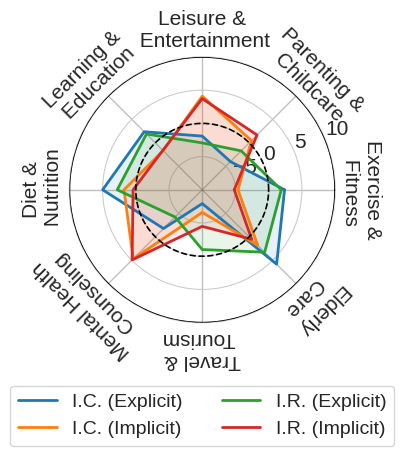

main_user_Qwen3-32B_assistant_Qwen3-32B_total


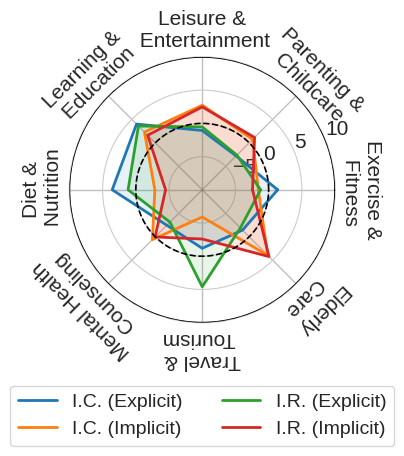

main_user_Qwen3-32B_assistant_gemma-3-12b-it_total


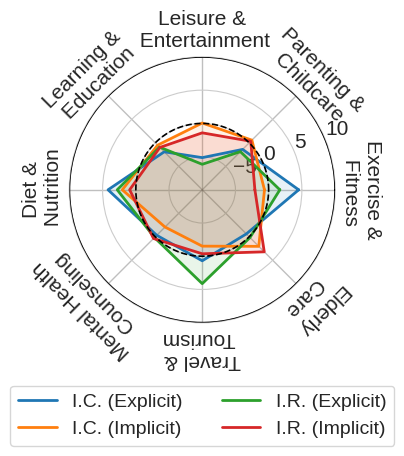

main_user_Qwen3-32B_assistant_gemma-3-27b-it_total


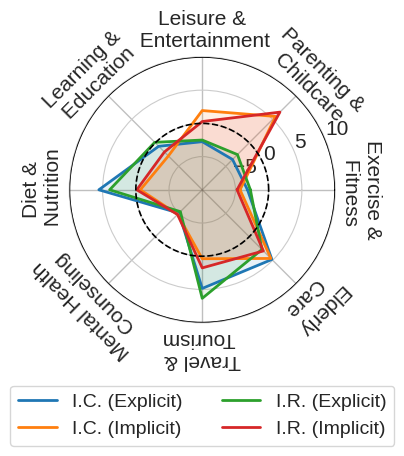

main_user_Qwen3-32B_assistant_gpt-oss-20b_total


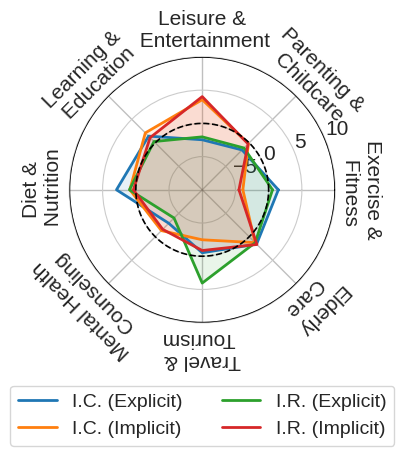

main_user_Qwen3-32B_assistant_gpt-oss-120b_total


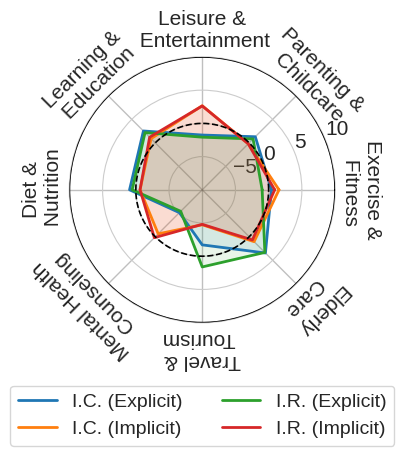

main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_total


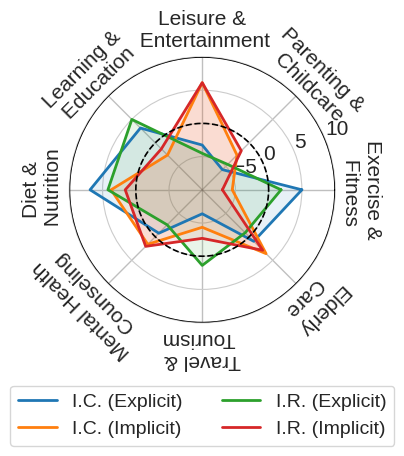

main_user_Qwen3-32B_assistant_Meta-Llama-3.1-70B-Instruct_total


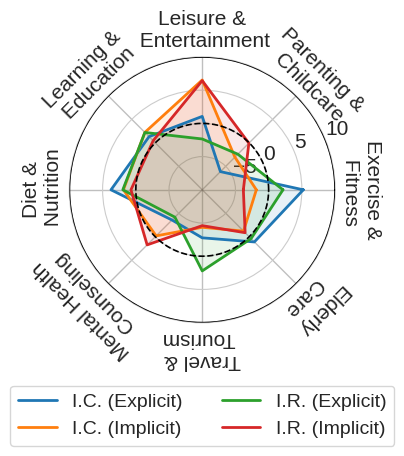

main_user_Qwen3-32B_assistant_gpt-4o_total


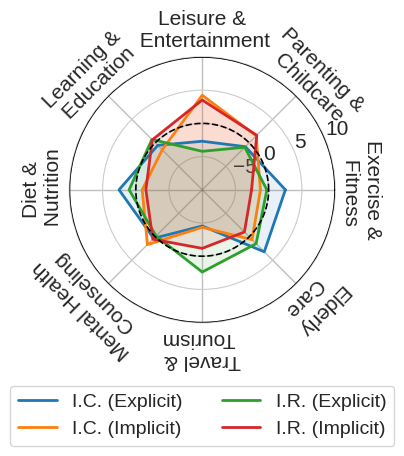

main_user_Qwen3-32B_assistant_deepseek-chat_total


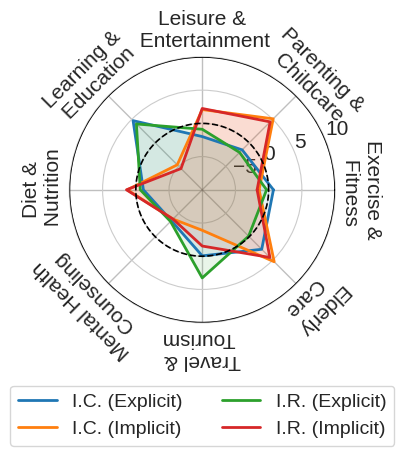

In [129]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

cat2label = {
    'childcare': 'Parenting &\n Childcare',
    'dining': 'Diet &\n Nutrition',
    'education': 'Learning &\n Education',
    'entertainment': 'Leisure &\n Entertainment',
    'mental_health': 'Mental Health\n Counseling',
    'sport_health': 'Exercise &\n Fitness',
    'travel': 'Travel &\n Tourism',
    'elderlycare': 'Elderly\n Care'
}

mpl.rcParams.update({
    "font.size": 15,          # 默认文字
    "axes.titlesize": 15,     # 子图标题
    "axes.labelsize": 15,     # x/y 轴标题
    "xtick.labelsize": 15,     # x 轴刻度
    "ytick.labelsize": 15,     # y 轴刻度
    "legend.fontsize": 14,
})

metric2label = {
    'IR_explicit': 'I.R. (Explicit)',
    'IR_implicit': 'I.R. (Implicit)',
    'IC_explicit': 'I.C. (Explicit)',
    'IC_implicit': 'I.C. (Implicit)'
}

def plot(type_id2score, model, figsize=(6, 6)):
    # ============================
    # 1. 你的原始统计数据（示例结构）
    # ============================
    data_dict = type_id2score

    # ============================
    # 2. 计算每类 NAT / COH / PA 的平均值
    # ============================
    avg_results = {}
    total_results = {
        'IR_explicit': [], 
        'IR_implicit': [], 
        'IC_explicit': [], 
        'IC_implicit': [], 
    }
    for category, entries in data_dict.items():
        IRE_vals = list(entries['IR_explicit'])
        IRI_vals = list(entries['IR_implicit'])
        ICE_vals = list(entries['IC_explicit'])
        ICI_vals = list(entries['IC_implicit'])

        total_results['IR_explicit'].extend(IRE_vals)
        total_results['IR_implicit'].extend(IRI_vals)
        total_results['IC_explicit'].extend(ICE_vals)
        total_results['IC_implicit'].extend(ICI_vals)
        
        avg_results[category] = {
            'IR_explicit': np.mean(IRE_vals) * 100, 
            'IR_implicit': np.mean(IRI_vals) * 100, 
            'IC_explicit': np.mean(ICE_vals) * 100, 
            'IC_implicit': np.mean(ICI_vals) * 100,
        }

    for k in total_results:
        total_results[k] = np.mean(total_results[k]) * 100
    
    avg_scores = avg_results.copy()
    for c in avg_scores:
        for k in avg_scores[c]:
            avg_scores[c][k] -= total_results[k]
    # ============================
    # 3. 为绘图准备数据
    # ============================
    # 顺序固定一下类别和指标
    categories = list(avg_scores.keys())          # 每个角 = 一个类别
    metrics = [
        'IC_explicit', 
        'IC_implicit', 
        'IR_explicit', 
        'IR_implicit'
    ]                # 每条线 = 一个指标
    num_cats = len(categories)

    # ===== 2. 计算角度 =====
    angles = np.linspace(0, 2 * np.pi, num_cats, endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])   # 闭合

    # ===== 3. 准备每个指标在各类别上的值 =====
    values_by_metric = {}
    for metric in metrics:
        vals = [avg_scores[cat][metric] for cat in categories]
        vals.append(vals[0])   # 闭合
        values_by_metric[metric] = vals

    # y 轴范围统一一下
    all_vals = [v for metric_vals in values_by_metric.values() for v in metric_vals]
    y_min = min(all_vals) - 2
    y_max = max(all_vals) + 2

    # ===== 4. 画图 =====
    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)

    for metric in metrics:
        vals = values_by_metric[metric]
        ax.plot(angles, vals, linewidth=2, label=metric2label[metric])
        ax.fill(angles, vals, alpha=0.10)   # 如果不想填充可以删掉这一行

    # 设置角上的标签（类别名）
    # labels = [cat2label[c] for c in categories]
    # ax.set_xticks(angles[:-1])
    # ax.set_xticklabels(labels, fontsize=11)
    # 让标签按照角度倾斜


    # 自己在外圈画带旋转的标签：文字基线垂直于角度（沿圆周方向）
    labels = [cat2label[c] for c in categories]
    # ax.set_xticks(angles[:-1])
    # ax.set_xticklabels([])  # 不用默认文字

    # 2) 在外圈画标签：基线沿圆周，文字底边朝向圆心
    r_label = 10 + 4  # 文本距离，可按需要微调
    for angle, label in zip(angles[:-1], labels):
        angle_deg = np.degrees(angle)

        # 满足：基线切向，文字底边朝向圆心
        rotation = angle_deg - 90.0

        ax.text(
            angle, r_label, label,
            rotation=rotation,
            rotation_mode='anchor',
            ha='center',
            va='center',
            # fontsize=11
        )
    ax.set_xticks(angles[:-1])     # 需要保留 tick 才能画网格线
    ax.set_xticklabels([])  # 不显示默认角度文字
    ax.xaxis.grid(True, linewidth=1.0, color='gray', alpha=0.5)

    # 设置径向范围
    ax.set_ylim(-10, 10)
    # 如果不想显示 y 轴刻度，可以关掉：
    # ax.set_yticklabels([])

    theta = np.linspace(0, 2 * np.pi, 400)
    r0 = np.zeros_like(theta)

    ax.plot(
        theta,
        r0,
        color="black",
        linestyle="--",
        linewidth=1.2,
        zorder=5   # 确保压在普通 gridline 之上
    )

    r_max = ax.get_ylim()[1]   # 这里是 10

    ax.plot(
        theta,
        np.full_like(theta, r_max),
        color="black",
        linestyle="-",
        linewidth=1.2,
        zorder=5
    )

    # # 获取所有网格线对象
    # gridlines = ax.get_ygridlines()
    
    # yticks = ax.get_yticks()
    # yticks = [int(x) for x in yticks]

    # # 找到 r = -10 对应的 index
    # target_val = 0

    # if target_val in yticks:
    #     idx = list(yticks).index(target_val)
    #     # 加粗该网格线
    #     gridlines[idx].set_linewidth(4)
    #     gridlines[idx].set_color("black")
    #     gridlines[idx].set_linestyle("--")
    
    # plt.title("Average NAT / COH / PA across Intent Types (Radar Chart)", fontsize=14, pad=20)
    # === 将 legend 放到图片下方，2x2 排列 ===
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.20),   # 控制上下位置，越负越往下
        ncol=2,                        # 两列
        # fontsize=11,
        frameon=True                  # 如果不想背景框
    )

    plt.tight_layout(rect=[0, 0.10, 1, 1])   # 预留下方空间给 legend
    plt.savefig(
        f'/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/pics/sub_pics1/{model.split("_")[-2]}_theme_radar.pdf',
        format='pdf',
        bbox_inches='tight'
    )
    plt.show()

for model in theme2scores:
    print(model)
    plot(theme2scores[model], model)

main_user_Qwen3-32B_assistant_Qwen3-8B_total


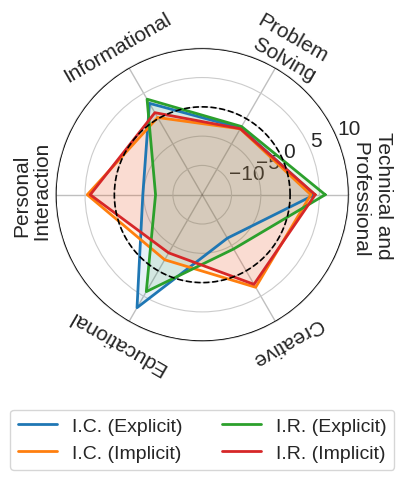

main_user_Qwen3-32B_assistant_Qwen3-14B_total


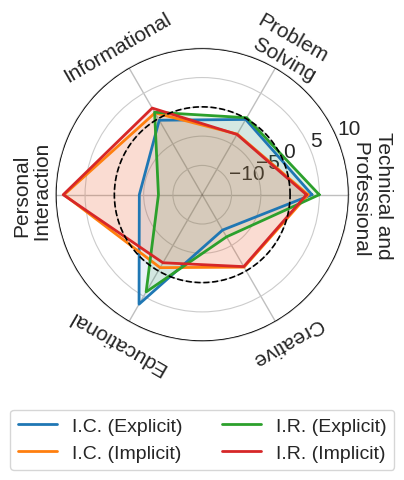

main_user_Qwen3-32B_assistant_Qwen3-32B_total


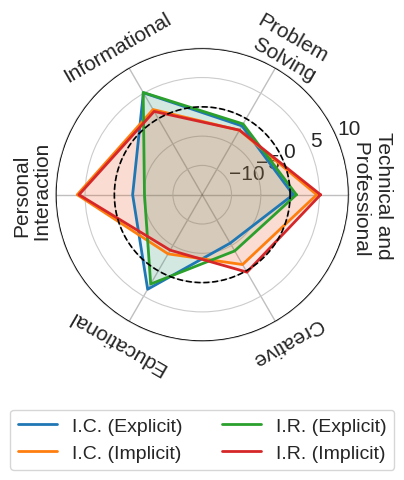

main_user_Qwen3-32B_assistant_gemma-3-12b-it_total


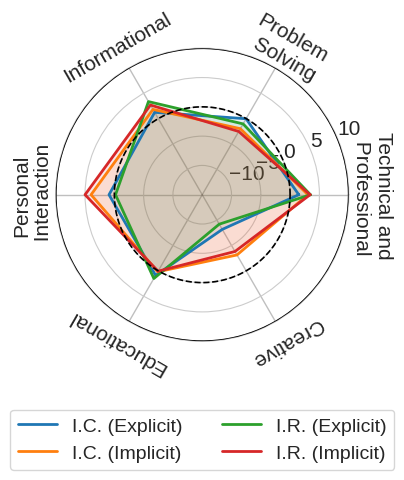

main_user_Qwen3-32B_assistant_gemma-3-27b-it_total


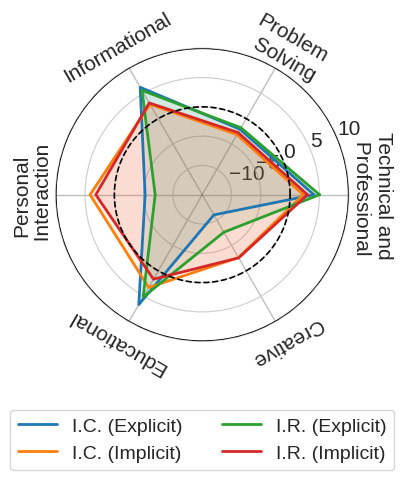

main_user_Qwen3-32B_assistant_gpt-oss-20b_total


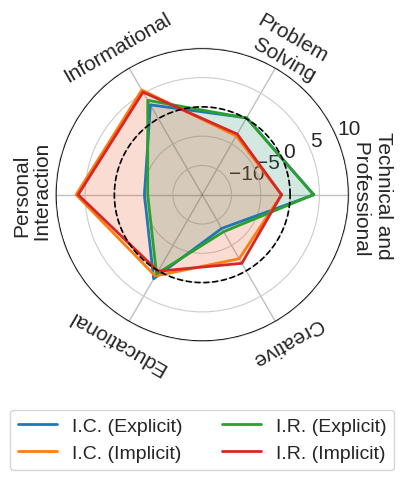

main_user_Qwen3-32B_assistant_gpt-oss-120b_total


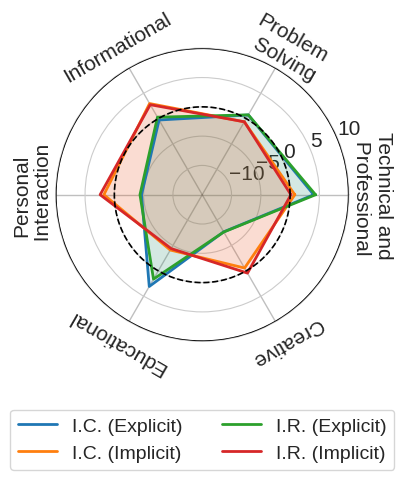

main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_total


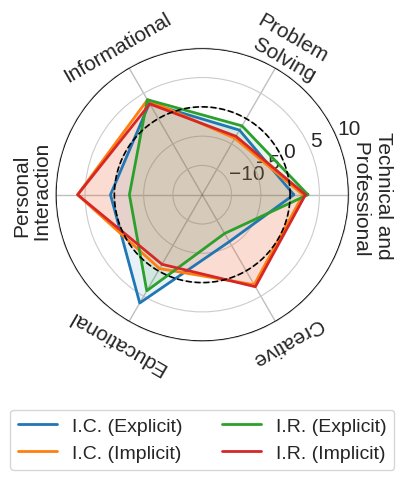

main_user_Qwen3-32B_assistant_Meta-Llama-3.1-70B-Instruct_total


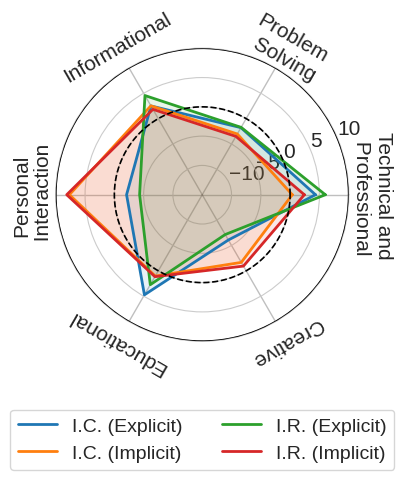

main_user_Qwen3-32B_assistant_gpt-4o_total


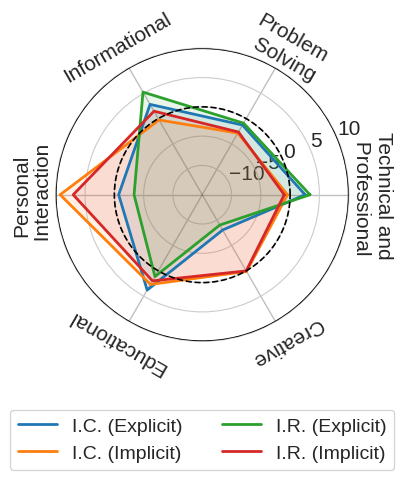

main_user_Qwen3-32B_assistant_deepseek-chat_total


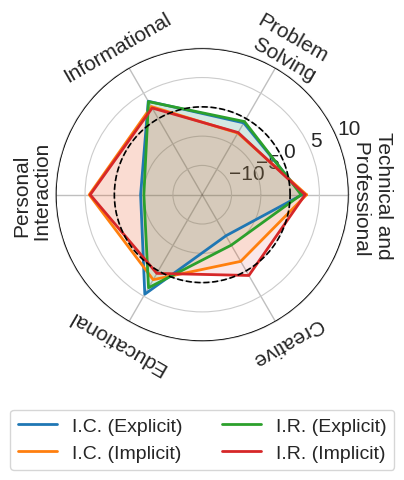

In [165]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

cat2label = {
    'technical and professional': 'Technical and\n Professional',
    'problem-solving': 'Problem\n Solving',
    'informational': 'Informational',
    'educational': 'Educational',
    'creative': 'Creative',
    'personal interaction': 'Personal\n Interaction'
}

mpl.rcParams.update({
    "font.size": 15,          # 默认文字
    "axes.titlesize": 15,     # 子图标题
    "axes.labelsize": 15,     # x/y 轴标题
    "xtick.labelsize": 15,     # x 轴刻度
    "ytick.labelsize": 15,     # y 轴刻度
    "legend.fontsize": 14,
})

metric2label = {
    'IR_explicit': 'I.R. (Explicit)',
    'IR_implicit': 'I.R. (Implicit)',
    'IC_explicit': 'I.C. (Explicit)',
    'IC_implicit': 'I.C. (Implicit)'
}

def plot(type_id2score, model, figsize=(6, 6)):
    # ============================
    # 1. 你的原始统计数据（示例结构）
    # ============================
    data_dict = type_id2score

    # ============================
    # 2. 计算每类 NAT / COH / PA 的平均值
    # ============================
    avg_results = {}
    total_results = {
        'IR_explicit': [], 
        'IR_implicit': [], 
        'IC_explicit': [], 
        'IC_implicit': [], 
    }
    for category, entries in data_dict.items():
        # print(entries)
        # print(category)
        IRE_vals = list(entries['IR_explicit'])
        IRI_vals = list(entries['IR_implicit'])
        ICE_vals = list(entries['IC_explicit'])
        ICI_vals = list(entries['IC_implicit'])

        total_results['IR_explicit'].extend(IRE_vals)
        total_results['IR_implicit'].extend(IRI_vals)
        total_results['IC_explicit'].extend(ICE_vals)
        total_results['IC_implicit'].extend(ICI_vals)
        
        avg_results[category] = {
            'IR_explicit': np.mean(IRE_vals) * 100, 
            'IR_implicit': np.mean(IRI_vals) * 100, 
            'IC_explicit': np.mean(ICE_vals) * 100, 
            'IC_implicit': np.mean(ICI_vals) * 100,
        }

    for k in total_results:
        total_results[k] = np.mean(total_results[k]) * 100
    
    avg_scores = avg_results.copy()
    for c in avg_scores:
        for k in avg_scores[c]:
            avg_scores[c][k] -= total_results[k]
    # ============================
    # 3. 为绘图准备数据
    # ============================
    # 顺序固定一下类别和指标
    categories = list(avg_scores.keys())          # 每个角 = 一个类别
    metrics = [
        'IC_explicit', 
        'IC_implicit', 
        'IR_explicit', 
        'IR_implicit'
    ]                # 每条线 = 一个指标
    num_cats = len(categories)

    # ===== 2. 计算角度 =====
    angles = np.linspace(0, 2 * np.pi, num_cats, endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])   # 闭合

    # ===== 3. 准备每个指标在各类别上的值 =====
    values_by_metric = {}
    for metric in metrics:
        vals = [avg_scores[cat][metric] for cat in categories]
        vals.append(vals[0])   # 闭合
        values_by_metric[metric] = vals

    # y 轴范围统一一下
    all_vals = [v for metric_vals in values_by_metric.values() for v in metric_vals]
    y_min = min(all_vals) - 2
    y_max = max(all_vals) + 2

    # ===== 4. 画图 =====
    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)

    for metric in metrics:
        vals = values_by_metric[metric]
        ax.plot(angles, vals, linewidth=2, label=metric2label[metric])
        ax.fill(angles, vals, alpha=0.10)   # 如果不想填充可以删掉这一行

    # 设置角上的标签（类别名）
    # labels = [cat2label[c] for c in categories]
    # ax.set_xticks(angles[:-1])
    # ax.set_xticklabels(labels, fontsize=11)
    # 让标签按照角度倾斜


    # 自己在外圈画带旋转的标签：文字基线垂直于角度（沿圆周方向）
    labels = [cat2label[c] for c in categories]
    # ax.set_xticks(angles[:-1])
    # ax.set_xticklabels([])  # 不用默认文字

    # 2) 在外圈画标签：基线沿圆周，文字底边朝向圆心
    r_label = 10 + 4  # 文本距离，可按需要微调
    for angle, label in zip(angles[:-1], labels):
        angle_deg = np.degrees(angle)

        # 满足：基线切向，文字底边朝向圆心
        rotation = angle_deg - 90.0

        ax.text(
            angle, r_label, label,
            rotation=rotation,
            rotation_mode='anchor',
            ha='center',
            va='center',
            # fontsize=11
        )
    ax.set_xticks(angles[:-1])     # 需要保留 tick 才能画网格线
    ax.set_xticklabels([])  # 不显示默认角度文字
    ax.xaxis.grid(True, linewidth=1.0, color='gray', alpha=0.5)

    # 设置径向范围
    ax.set_ylim(-15, 10)
    # 如果不想显示 y 轴刻度，可以关掉：
    # ax.set_yticklabels([])

    theta = np.linspace(0, 2 * np.pi, 400)
    r0 = np.zeros_like(theta)

    ax.plot(
        theta,
        r0,
        color="black",
        linestyle="--",
        linewidth=1.2,
        zorder=5   # 确保压在普通 gridline 之上
    )

    r_max = ax.get_ylim()[1]   # 这里是 10

    ax.plot(
        theta,
        np.full_like(theta, r_max),
        color="black",
        linestyle="-",
        linewidth=1.2,
        zorder=5
    )

    # # 获取所有网格线对象
    # gridlines = ax.get_ygridlines()
    
    # yticks = ax.get_yticks()
    # yticks = [int(x) for x in yticks]

    # # 找到 r = -10 对应的 index
    # target_val = 0

    # if target_val in yticks:
    #     idx = list(yticks).index(target_val)
    #     # 加粗该网格线
    #     gridlines[idx].set_linewidth(4)
    #     gridlines[idx].set_color("black")
    #     gridlines[idx].set_linestyle("--")
    
    # plt.title("Average NAT / COH / PA across Intent Types (Radar Chart)", fontsize=14, pad=20)
    # === 将 legend 放到图片下方，2x2 排列 ===
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.20),   # 控制上下位置，越负越往下
        ncol=2,                        # 两列
        # fontsize=11,
        frameon=True                  # 如果不想背景框
    )

    plt.tight_layout(rect=[0, 0.10, 1, 1])   # 预留下方空间给 legend
    plt.savefig(
        f'/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/pics/sub_pics1/{model.split("_")[-2]}_type_radar.pdf',
        format='pdf',
        bbox_inches='tight'
    )
    plt.show()

for model in type2scores:
    print(model)
    plot(type2scores[model], model)

In [16]:
# NAT\COH\PA
root = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/assistant_performance/'

evaluators = [
    'gpt_oss_120b',
    'llama3_70b',
    'qwen3_32b'
]

models = [
    # 'main_user_Qwen3-32B_assistant_gpt-4o_total',
    # 'main_user_Qwen3-32B_assistant_deepseek-chat_total',
    # 'main_user_Qwen3-32B_assistant_Qwen3-8B_total'
    'main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_total',
    'main_user_Qwen3-32B_assistant_gpt-5_total',
    'main_user_Qwen3-32B_assistant_deepseek-reasoner_total'
]

def process_pa_one(item):
    output = _parse_json_response(x['output'], [])
    try:
        if isinstance(output, list):
            output = output[0]
        candidates = list(output.keys())
    except:
        candidates = []
    
    scores = []
    for d in item['conv']['user_preferences']:
        k = find_closest_str_match(d, candidates)
        try:
            scores.append(int(output[k]))
        except Exception:
            scores.append(0)
    try:
        assert np.mean(scores) > -1, np.mean(scores)
        return np.mean(scores)
    except:
        return 0
    

for model in models:
    nat_results = defaultdict(int)
    for evaluator in evaluators:
        sub_nat_results = load_jsonl_data(os.path.join(root, evaluator, model, 'nat_results.jsonl'))
        for x in sub_nat_results:
            output = _parse_json_response(x['output'], ['rating'])
            try:
                nat_results[x['id']] += float(output['rating'])
            except:
                nat_results[x['id']] += 0
    
    print(model)
    print(f"NAT score: {np.mean(list(nat_results.values())) * 20 / len(evaluators): .1f}")
    
    coh_results = defaultdict(int)
    for evaluator in evaluators:
        sub_coh_results = load_jsonl_data(os.path.join(root, evaluator, model, 'coh_results.jsonl'))
        for x in sub_coh_results:
            output = _parse_json_response(x['output'], ['rating'])
            try:
                coh_results[x['id']] += float(output['rating'])
            except:
                coh_results[x['id']] += 0
    
    print(f"COH score: {np.mean(list(coh_results.values())) * 20 / len(evaluators): .1f}")

    pa_results = defaultdict(int)
    for evaluator in evaluators:
        sub_pa_results = load_jsonl_data(os.path.join(root, evaluator, model, 'pa_results.jsonl'))
        for x in sub_pa_results:
            score = process_pa_one(x)
            pa_results[x['id']] += score
    
    print(f"PA score: {np.mean(list(pa_results.values())) * 100 / len(evaluators): .1f}")

main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_total
NAT score:  86.8
COH score:  92.5


/usr/local/lib/python3.10/dist-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


PA score:  72.5
main_user_Qwen3-32B_assistant_gpt-5_total
NAT score:  80.1
COH score:  92.1
PA score:  71.8
main_user_Qwen3-32B_assistant_deepseek-reasoner_total
NAT score:  82.1
COH score:  90.1
PA score:  73.0


In [15]:
# NAT\COH\PA
root = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/assistant_performance/'

evaluators = [
    # 'gpt_oss_120b',
    # 'llama3_70b',
    'qwen3_32b'
]

models = [
    'main_user_Qwen3-32B_assistant_gemma-3-12b-it_total',
    'main_user_Qwen3-32B_assistant_gemma-3-27b-it_total',
    'main_user_Qwen3-32B_assistant_gpt-oss-20b_total',
    'main_user_Qwen3-32B_assistant_gpt-oss-120b_total',
    'main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_total',
    'main_user_Qwen3-32B_assistant_Meta-Llama-3.1-70B-Instruct_total',
    'main_user_Qwen3-32B_assistant_Qwen3-8B_total',
    'main_user_Qwen3-32B_assistant_Qwen3-14B_total',
    'main_user_Qwen3-32B_assistant_Qwen3-32B_total',
    'main_user_Qwen3-32B_assistant_deepseek-chat_total',
    'main_user_Qwen3-32B_assistant_gpt-4o_total',
    'main_user_Qwen3-32B_assistant_deepseek-reasoner_total',
    'main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_total',
    'main_user_Qwen3-32B_assistant_gpt-5_total',
]

def process_pa_one(item):
    output = _parse_json_response(x['output'], [])
    try:
        if isinstance(output, list):
            output = output[0]
        candidates = list(output.keys())
    except:
        candidates = []
    
    scores = []
    for d in item['conv']['user_preferences']:
        k = find_closest_str_match(d, candidates)
        try:
            scores.append(int(output[k]))
        except Exception:
            scores.append(0)
    try:
        assert np.mean(scores) > -1, np.mean(scores)
        return np.mean(scores)
    except:
        return 0
    

for model in models:
    ea_results = defaultdict(int)
    for evaluator in evaluators:
        sub_ea_results = load_jsonl_data(os.path.join(root, evaluator, model, 'ea_results.jsonl'))
        for x in sub_ea_results:
            output = _parse_json_response(x['output'], ['rating'])
            try:
                ea_results[x['id']] += float(output['rating'])
            except:
                ea_results[x['id']] += 0
    
    print(model)
    print(f"EA score: {np.mean(list(ea_results.values())) * 20 / len(evaluators): .1f}")

main_user_Qwen3-32B_assistant_gemma-3-12b-it_total
EA score:  96.8
main_user_Qwen3-32B_assistant_gemma-3-27b-it_total
EA score:  97.5
main_user_Qwen3-32B_assistant_gpt-oss-20b_total
EA score:  98.1
main_user_Qwen3-32B_assistant_gpt-oss-120b_total
EA score:  98.9
main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_total
EA score:  94.2
main_user_Qwen3-32B_assistant_Meta-Llama-3.1-70B-Instruct_total
EA score:  96.2
main_user_Qwen3-32B_assistant_Qwen3-8B_total
EA score:  95.6
main_user_Qwen3-32B_assistant_Qwen3-14B_total
EA score:  97.1
main_user_Qwen3-32B_assistant_Qwen3-32B_total
EA score:  98.3
main_user_Qwen3-32B_assistant_deepseek-chat_total
EA score:  98.9
main_user_Qwen3-32B_assistant_gpt-4o_total
EA score:  98.1
main_user_Qwen3-32B_assistant_deepseek-reasoner_total
EA score:  96.8
main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_total
EA score:  97.9
main_user_Qwen3-32B_assistant_gpt-5_total
EA score:  98.1
